In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays
using StatsBase
using CairoMakie
using LaTeXStrings

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Determine eq and threshold

In [46]:
# lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
lambdas = [13.0, 15.0, 20.0, 50.0]


# vel = [10.0]
vel = [5.0, 10.0, 20.0, 100.0]
tms = [1.0, 2.0, 4.0, 10.0]
steps = 120000

for (idx_v, v) in enumerate(vel)
    for (idx_t, tm) in enumerate(tms)
        rows = 1
        cols = 4
        fig2 = Figure(size=(900 * cols, 600 * rows))

        for (idx, lambda) in enumerate(lambdas)
        
            filename = @sprintf("fsb_tm_%s_v_%s_n_%s.jld2", tm, v, lambda)
            
            row = ceil(Int, idx / cols)
            col = (idx - 1) % cols + 1
            
            ax = Axis(fig2[1, col], 
                    xlabel="Time (s)", 
                    ylabel="Distance to source (X)",
                    title="Λ = $lambda")

            jldopen(filename, "r") do file 
                for agent in 1:100
                    mean_dist_x = Float64[] 
                    for step in 100:100:steps
            
                        g = file[@sprintf("step_%06d", step)]

                        other_x = g["x"][agent]
                        dists_x = other_x .- 0

                        push!(mean_dist_x, mean(dists_x))
        
                    end

                    # Plotting X data
                    lines!(ax, (100:100:steps)*0.01, mean_dist_x, label="Mean X")
                end
            end
        end
        save("Plots/Fixed_source_model/Next/All/Trajectories_tm$(tm)_v$(v).pdf", fig2)
    end
end

# Load dc and delta, threshold and eq time

In [5]:
df_times = CSV.read("df_times_all.csv", DataFrame)

Row,tm,n,v,Dc,delta,l,Lambda,eq,threshold
,Int64,String7,Int64,String15,String15,String15,String15,Int64,Int64
1,1,"0,25",10,40,"0,0025","126,4911064","0,0790569415",50000,100
2,1,"0,5",10,20,"0,005","63,2455532","0,158113883",50000,75
3,1,"0,75",10,"13,33333333","0,0075","42,16370214","0,2371708245",50000,75
4,1,1,10,10,"0,01","31,6227766","0,316227766",50000,75
5,1,2,10,5,"0,02","15,8113883","0,632455532",50000,50
6,1,3,10,"3,333333333","0,03","10,54092553","0,9486832981",50000,50
7,1,4,10,"2,5","0,04","7,90569415","1,264911064",50000,50
8,1,5,10,2,"0,05","6,32455532","1,58113883",50000,50
9,1,6,10,"1,666666667","0,06","5,270462767","1,897366596",50000,50


o

In [2]:
dc_delta_all = CSV.read("df_times_all.csv", DataFrame)
dc_delta_all.n = parse.(Float64, replace.(dc_delta_all.n, "," => "."))
dc_delta_all.Dc = parse.(Float64, replace.(dc_delta_all.Dc, "," => "."))
dc_delta_all.delta = parse.(Float64, replace.(dc_delta_all.delta, "," => "."))
dc_delta_all.l = parse.(Float64, replace.(dc_delta_all.l, "," => "."))

208-element Vector{Float64}:
  126.4911064
   63.2455532
   42.16370214
   31.6227766
   15.8113883
   10.54092553
    7.90569415
    6.32455532
    5.270462767
    4.517539515
    ⋮
 1581.13883
 1054.092553
  790.569415
  632.455532
  527.0462767
  451.7539515
  395.2847075
  351.3641845
  316.227766

# Separate populations

In [9]:
function check_agent(file, step, agent_idx, threshold)

    data = file[@sprintf("step_%06d", step)]
    
    x = data["x"][agent_idx]
    y = data["y"][agent_idx]
    
    return (x <= threshold) && (y <= threshold) && (x >= -threshold) && (y >= -threshold)
end

check_agent (generic function with 1 method)

In [10]:
# dfs_all = Dict{Tuple{Float64, Float64, Float64}, DataFrame}()

# lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
lambdas = [13.0, 15.0, 20.0, 50.0]


tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

N_agents = 1000
end_step = 120000

for (v_idx, v) in enumerate(vel)
    for (t_idx, tm) in enumerate(tms)
        for (l_idx, lambda) in enumerate(lambdas)

            filename = @sprintf("fsb_tm_%s_v_%s_n_%s.jld2", tm, v, lambda)
            println("Processing $filename")

            # # lookup metadata
            filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.n .== 10, :]

            # if nrow(row) == 0
            #     println("  ⚠️ Skipping (not found in df_times)")
            #     continue
            # end

            start_step = row.eq[1]

            threshold_distance = row.threshold[1]

            # -----------------------------
            # STEP 1: find valid agents
            # -----------------------------
            valid_agents = Int[]

            jldopen(filename, "r") do file
                for agent_idx in 1:N_agents
                    is_valid = true

                    for step in start_step:100:end_step
                        if !check_agent(file, step, agent_idx, threshold_distance)
                            is_valid = false
                            break
                        end
                    end

                    if is_valid
                        push!(valid_agents, agent_idx)
                    end
                end
            end

            println("  ✔ valid agents: $(length(valid_agents))")

            # -----------------------------
            # STEP 2: extract trajectories
            # -----------------------------
            steps_vec = Int[]
            agents_vec = Int[]
            x_vec = Float64[]
            y_vec = Float64[]
            
            jldopen(filename, "r") do file
                for agent in valid_agents
                    for step in 100:100:end_step
                        g = file[@sprintf("step_%06d", step)]

                        push!(steps_vec, step)
                        push!(agents_vec, agent)
                        push!(x_vec, g["x"][agent])
                        push!(y_vec, g["y"][agent])
                    end
                end
            end

            df = DataFrame(
                step = steps_vec,
                agent = agents_vec,
                x = x_vec,
                y = y_vec
            )

            # store in dict
            dfs_all[(tm, v, lambda)] = df

        end
    end
end

Processing fsb_tm_1.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 421
Processing fsb_tm_1.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 188
Processing fsb_tm_1.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 12
Processing fsb_tm_1.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 0
Processing fsb_tm_2.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 734
Processing fsb_tm_2.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 714
Processing fsb_tm_2.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 545
Processing fsb_tm_2.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 0
Processing fsb_tm_4.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 751
Processing fsb_tm_4.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 726
Processing fsb_tm_4.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 610
Processing fsb_tm_4.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 121
Processing fsb_tm_10.0_v_5.0_n_13.0.jld2
  ✔ valid agents: 765
Processing fsb_tm_10.0_v_5.0_n_15.0.jld2
  ✔ valid agents: 718
Processing fsb_tm_10.0_v_5.0_n_20.0.jld2
  ✔ valid agents: 656
Processing fsb_tm_10.0_v_5.0_n_50.0.jld2
  ✔ valid agents: 294
Processin

In [11]:
@save "dfs_all.jld2" dfs_all
@save "dc_delta_all.jld2" dc_delta_all

In [16]:
@load "dfs_all.jld2" dfs_all
@load "dc_delta_all.jld2" dc_delta_all


1-element Vector{Symbol}:
 :dc_delta_all

# Extract k and D, calculate escape probability

In [3]:
function linear_fit_mx(x, y)
    """Linear regression constrained to pass through origin: y = m*x"""
    slope = sum(x .* y) / sum(x.^2)
    return slope
end

linear_fit_mx (generic function with 1 method)

In [13]:
# metrics_all = DataFrame(
#     tm = Float64[],
#     v = Float64[],
#     l = Float64[],
#     mu = Float64[],
#     sigma = Float64[],
#     variance = Float64[],
#     k = Float64[],
#     D = Float64[],
#     P_esc = Float64[]
# )

# lambdas = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
lambdas = [13.0, 15.0, 20.0, 50.0]

tms = [1.0, 2.0, 4.0, 10.0]
# tms = [10.0]
vel = [5.0, 10.0, 20.0, 100.0]

for (idx, l) in enumerate(lambdas)
    for (t_idx, tm) in enumerate(tms)
        for (v_idx, v) in enumerate(vel)

            df = dfs_all[(tm, v, l)]

            filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.n .== 10.0, :]

            if nrow(row) == 0
                continue
            end

            eq_step = row.eq[1]

            if ismissing(eq_step)
                println("Skipping $tm, $l (missing params)")
                continue
            end

            # =========================
            # SPLIT DATA
            # =========================
            eq = df[df.step .>= eq_step, :]

            # =========================
            # EQUILIBRIUM STATS
            # =========================
            mu_x = mean(eq.x)
            mu_y = mean(eq.y)

            mu = (mu_x + mu_y) / 2

            sigma_x = std(eq.x)
            sigma_y = std(eq.y)

            sigma = (sigma_x + sigma_y) / 2

            variance_x = var(eq.x)
            variance_y = var(eq.y)

            variance = (variance_x + variance_y) / 2

            len_data = length(unique(eq.step))
            lag_data = len_data - 100
            lags = (1:1:lag_data)

            grouped_ag = groupby(eq, :agent)
            correlations = zeros(length(grouped_ag), length(lags))
            correlations_y = zeros(length(grouped_ag), length(lags))

            # Calculate escape probability
            P_esc = 1 - (length(grouped_ag) / 1000)

            for i in 1:length(grouped_ag)
                df_ag = grouped_ag[i]
                traj = df_ag.x
                traj_y = df_ag.y
                cor = autocor(traj, lags; demean = false)
                cor_y = autocor(traj_y, lags; demean = false)
                correlations[i, :] = cor
                correlations_y[i, :] = cor_y
            end

            correlations_mean = Float64[]
            correlations_mean_y = Float64[]
            correlations_std_x = Float64[]
            correlations_std_y = Float64[]

            for i in 1:length(lags)
                lag_mean = correlations[:, i]
                lag_mean_y = correlations_y[:, i]
                push!(correlations_mean, mean(lag_mean))
                push!(correlations_std_x, std(lag_mean))
                push!(correlations_mean_y, mean(lag_mean_y))
                push!(correlations_std_y, std(lag_mean_y))
            end

            fig = Figure(size=(900, 500))

            ax1 = Axis(fig[1, 1], title="Correlation")
            ax2 = Axis(fig[1, 2], title="Logarithm")


            logx_std = log.(correlations_std_x)
            logx = log.(abs.(correlations_mean))

            logy_std = log.(correlations_std_y)
            logy = log.(abs.(correlations_mean_y))
            println("$tm, $l")

            time_005_x = findall(correlations_mean .<= 0.1)[1]
            time_005_y = findall(correlations_mean_y .<= 0.1)[1]
        
            slope_x = linear_fit_mx(lags[1:time_005_x], logx[1:time_005_x])
            slope_y = linear_fit_mx(lags[1:time_005_y], logx[1:time_005_y])

            k_x = -slope_x * 10
            k_y = -slope_y * 10

            lines!(ax1, lags, correlations_mean)
            lines!(ax1, lags[1:time_005_x], exp.(slope_x .* lags[1:time_005_x]), color = :red, linestyle = :dash)
            lines!(ax2, lags, logx)
            lines!(ax2, lags[1:time_005_x], slope_x .* lags[1:time_005_x], color=:red, linestyle=:dash)
            band!(ax2, lags, logx .+ logx_std, logx .- logx_std, color = (:blue, 0.2))

            # xlims!(ax1, 0, 1000)
            # xlims!(ax2, 0, 1000)
            # hidedecorations!(ax1)
            ax1.topspinevisible = false
            ax1.rightspinevisible = false
            ax1.ygridvisible = false
            ax1.xgridvisible = false
            ax2.topspinevisible = false
            ax2.rightspinevisible = false
            ax2.ygridvisible = false
            ax2.xgridvisible = false

            save("Plots/Fixed_source_model/Next/All/cor_tm$(tm)_v$(v)_n$(l).pdf", fig)

            k = (k_x + k_y) / 2
            D = variance * k

            # =========================
            # STORE METRICS
            # # =========================
            push!(metrics_all, (
                tm,
                v,
                l,
                mu,
                sigma,
                variance,
                k,
                D,
                P_esc
            ))
        end
    end
end

1.0, 13.0
1.0, 13.0
1.0, 13.0
1.0, 13.0
2.0, 13.0
2.0, 13.0
2.0, 13.0
2.0, 13.0
4.0, 13.0
4.0, 13.0
4.0, 13.0
4.0, 13.0
10.0, 13.0
10.0, 13.0
10.0, 13.0
10.0, 13.0
1.0, 15.0
1.0, 15.0
1.0, 15.0
1.0, 15.0
2.0, 15.0
2.0, 15.0
2.0, 15.0
2.0, 15.0
4.0, 15.0
4.0, 15.0
4.0, 15.0
4.0, 15.0
10.0, 15.0
10.0, 15.0
10.0, 15.0
10.0, 15.0
1.0, 20.0
1.0, 20.0
1.0, 20.0
1.0, 20.0
2.0, 20.0
2.0, 20.0
2.0, 20.0
2.0, 20.0
4.0, 20.0
4.0, 20.0
4.0, 20.0
4.0, 20.0
10.0, 20.0
10.0, 20.0
10.0, 20.0
10.0, 20.0
1.0, 50.0


BoundsError: BoundsError: attempt to access 0-element Vector{Int64} at index [1]

In [14]:
@save "metrics_all.jld2" metrics_all

In [17]:
@load "metrics_all.jld2" metrics_all

1-element Vector{Symbol}:
 :metrics_all

# Plots

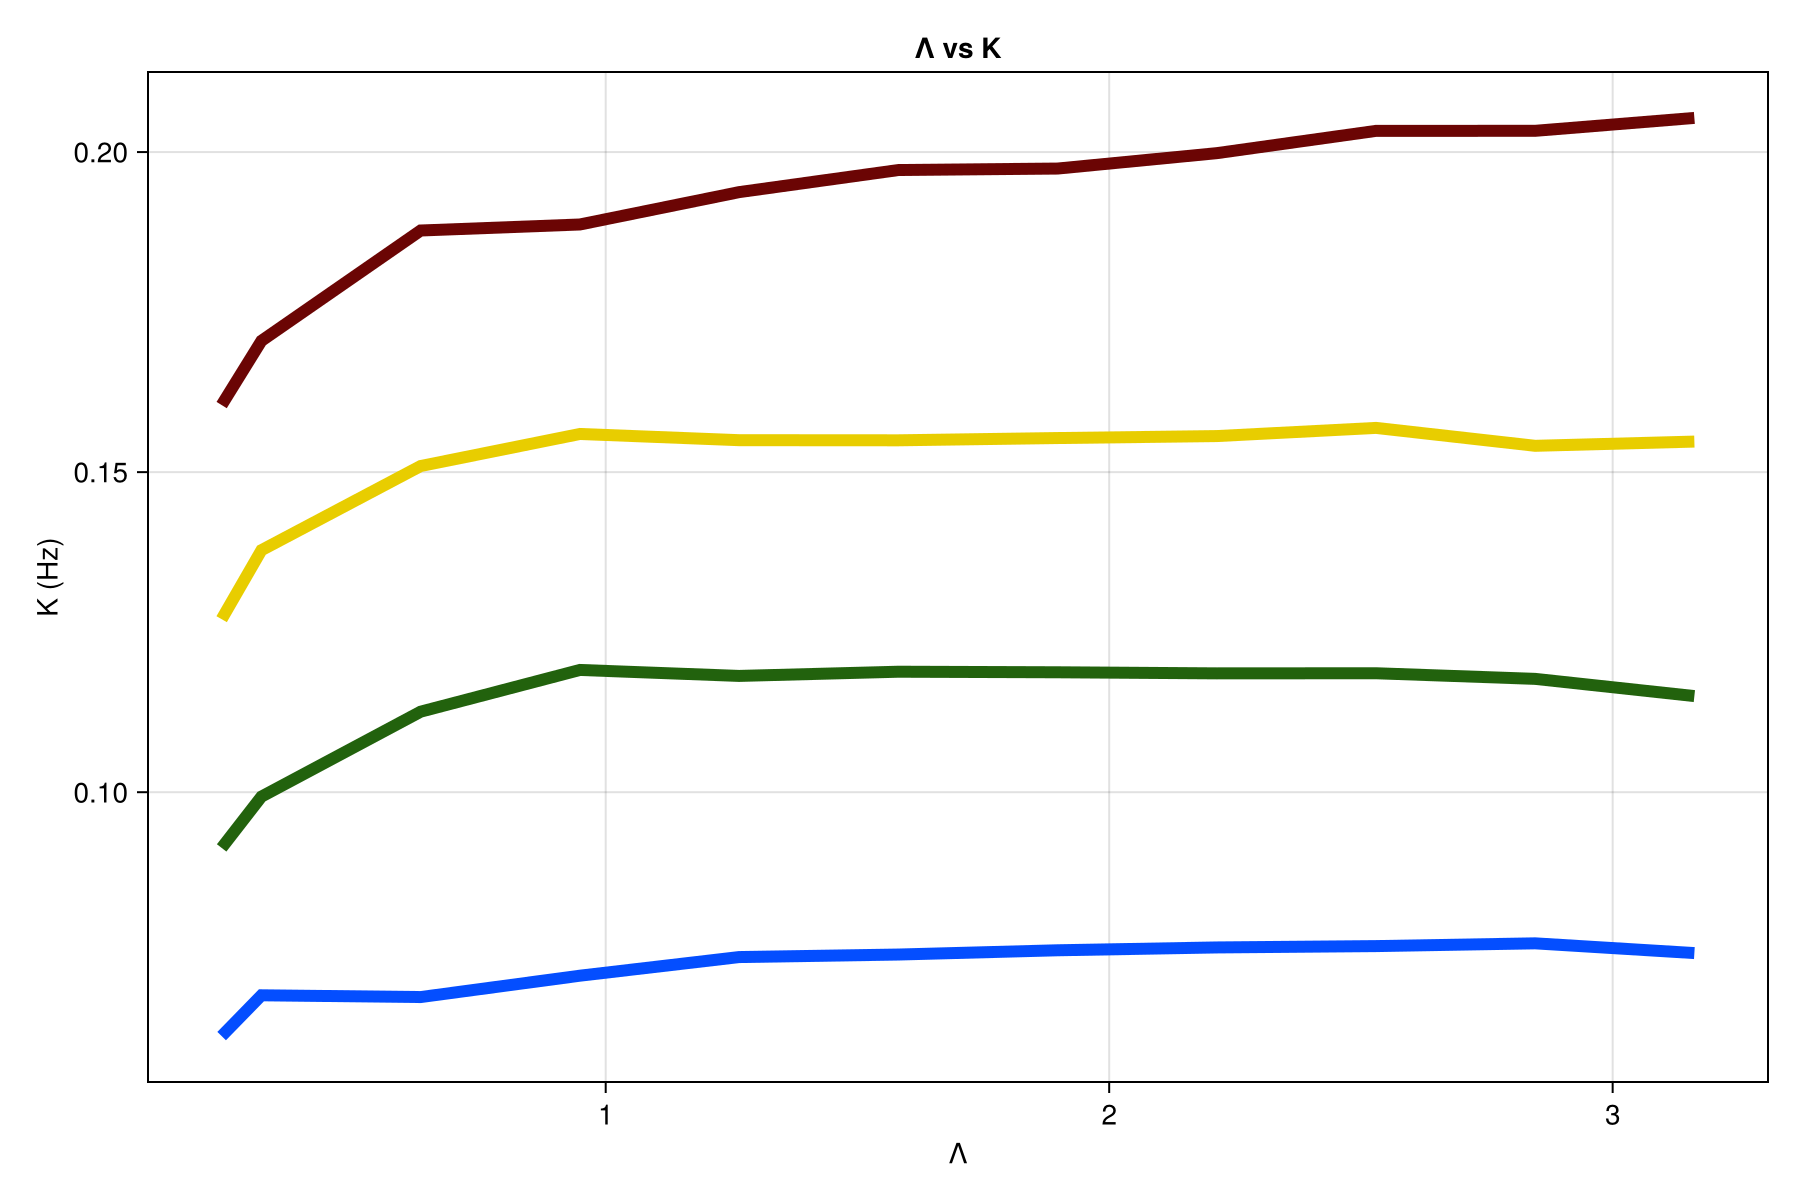

In [141]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [ 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))
# ax_k = Axis(fig[1,1], title = "Λ vs D", xlabel = "Λ", ylabel = "D")
ax_k = Axis(fig[1,1], title = "Λ vs K", xlabel = "Λ", ylabel = "K (Hz)")
# ax_D = Axis(fig[1,2], title = "Λ vs Variance", xlabel = "Λ", ylabel = L"Variance ($\mu m^2$)")
# ax_D = Axis(fig[1,2], title = "Λ vs D", xlabel = "Λ", ylabel = L"D ($\frac{\mu m^2}{s}$)")
# ax_P = Axis(fig[1,1], title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ", xlabel = L"log($\Lambda$)", ylabel = L"log (P(esc) $\sqrt{\tau _m}$)")
# ax_P = Axis(fig[1,1], title = "Λ vs P(esc)", xlabel = "Λ", ylabel = "P(esc)")
lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]
mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

for (idx_t, tm) in enumerate(tms)
        mean_tms_k = zeros(4, 14)
        mean_tms_D = zeros(4, 14)
        mean_tms_P = zeros(4, 14)


    for (idx_v, v) in enumerate(vel)
        k_v = []
        D_v = []
        P_v = []
        v_l = []


        for (idx_l, l) in enumerate(lambdas)
            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            # filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            # filter_2 = filter_1[filter_1.v .== v, :]
            # row2 = filter_2[filter_2.n .== l, :]

            # field = row2.l[1]
            k = row.k[1]
            D = row.D[1]
            P_esc = row.P_esc[1]
            # vl = v / field

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
            # push!(v_l, field)
        end
       
        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v



        lines!(ax_P,log.(lambdas_x[3:14]) ,log.(P_v[3:14] .* sqrt(tm)), color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P,range(-0.5,1),range(-0.5,1), label ="m=1", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_k, lambdas_x, k_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_D, lambdas_x, D_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P, lambdas_x, P_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        
        

    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        push!(mean_D, mean(mean_tms_D[:, i]))
        push!(mean_P, mean(mean_tms_P[:, i]))
        
    end

    lines!(ax_k, lambdas_x[1:11], mean_k[1:11], linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_D, lambdas_x, mean_D, linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_P, lambdas_x, mean_P, linewidth = 6, label ="$tm", color = colors[idx_t])
    
    # slope, intercept = linear_fit(log.(lambdas_x[3:14]), log.(mean_P[3:14]))
    # lines!(ax_P, log.(lambdas_x[3:14]), intercept .+  log.(lambdas_x[3:14]) .* slope, linestyle = :dash, color = :red, label = "$slope")
end  

# ax_k.topspinevisible = false
# ax_k.rightspinevisible = false
# ax_k.ygridvisible = false
# ax_k.xgridvisible = false

# ax_D.topspinevisible = false
# ax_D.rightspinevisible = false
# ax_D.ygridvisible = false
# ax_D.xgridvisible = false

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

# fig[1,2] = Legend(fig, ax_P, "V") # ?

fig            


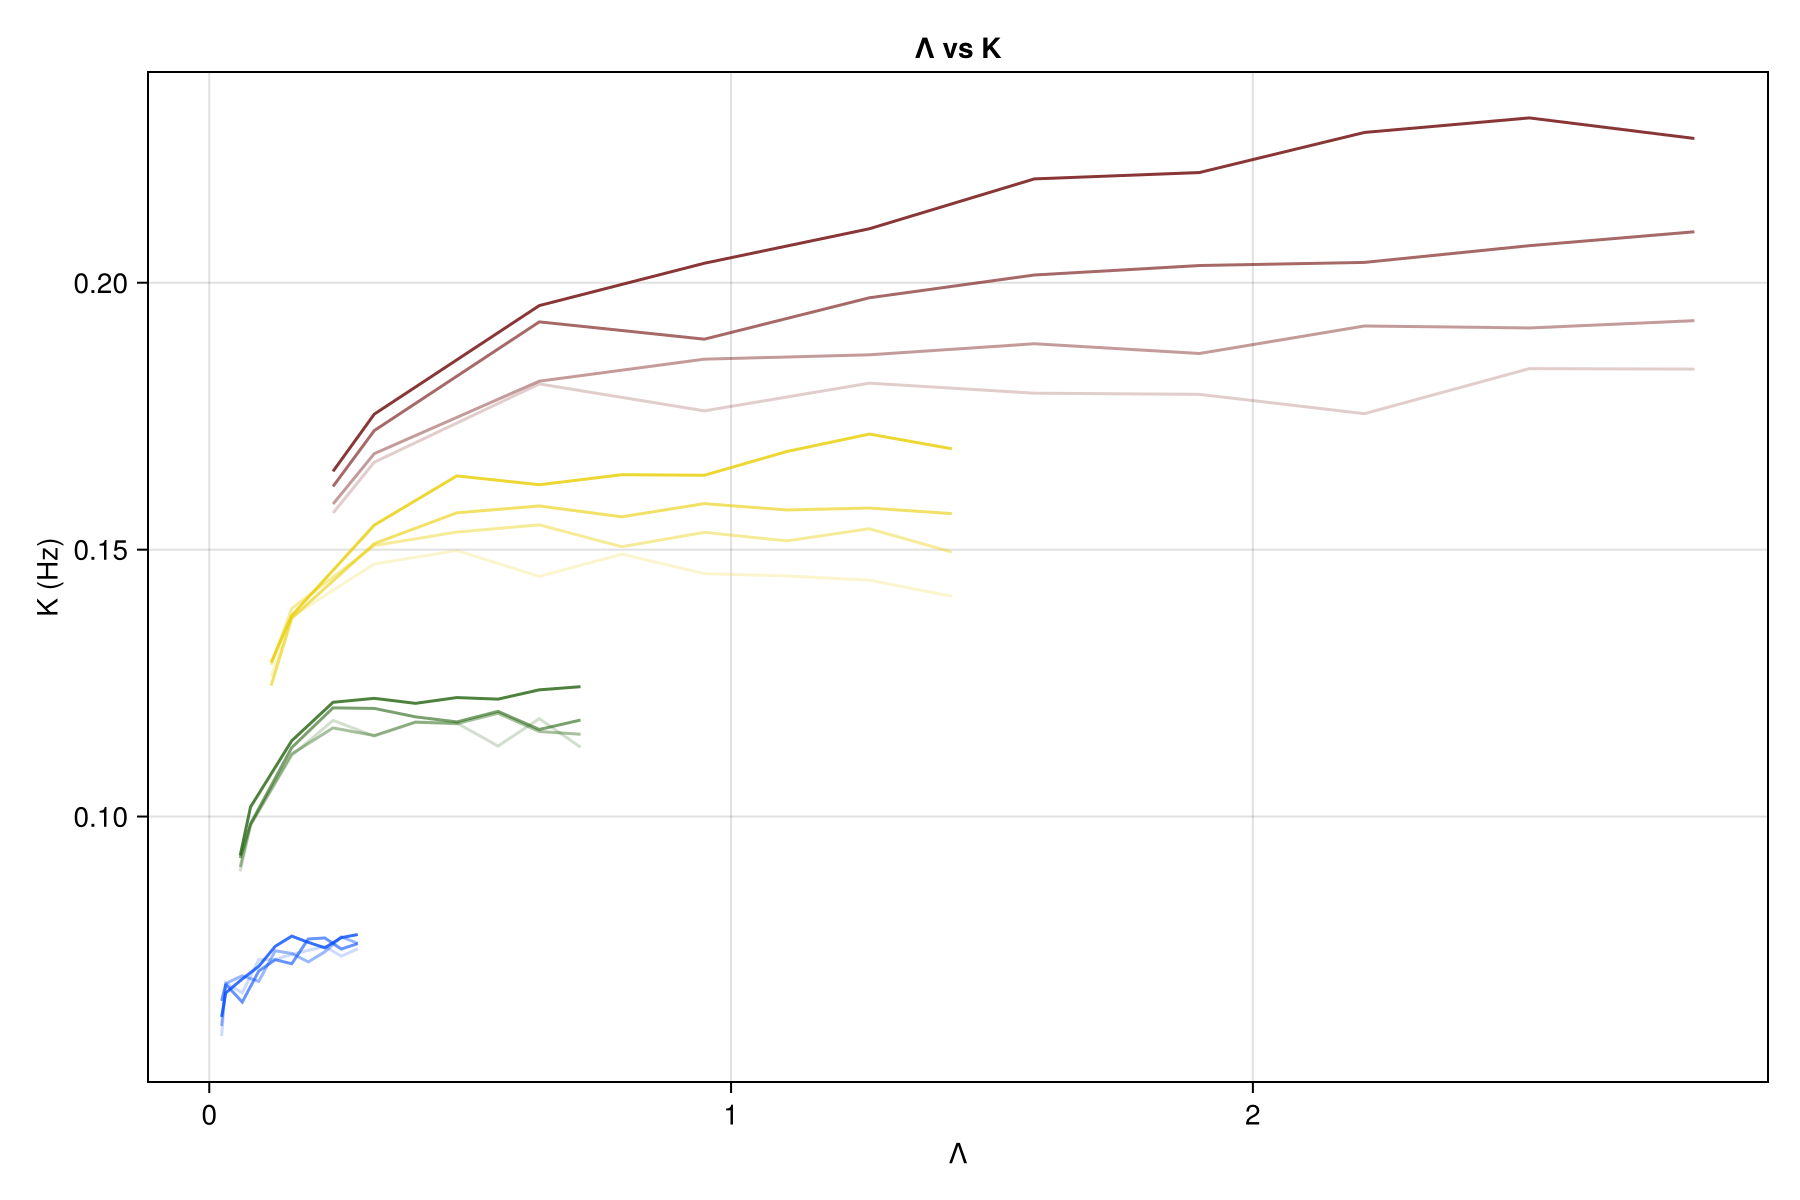

In [197]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [ 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))
# ax_k = Axis(fig[1,1], title = "Λ vs D", xlabel = "Λ", ylabel = "D")
ax_k = CairoMakie.Axis(fig[1,1], title = "Λ vs K", xlabel = "Λ", ylabel = "K (Hz)")
# ax_D = Axis(fig[1,2], title = "Λ vs Variance", xlabel = "Λ", ylabel = L"Variance ($\mu m^2$)")
# ax_D = Axis(fig[1,2], title = "Λ vs D", xlabel = "Λ", ylabel = L"D ($\frac{\mu m^2}{s}$)")
# ax_P = Axis(fig[1,1], title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ", xlabel = L"log($\Lambda$)", ylabel = L"log (P(esc) $\sqrt{\tau _m}$)")
# ax_P = Axis(fig[1,1], title = "Λ vs P(esc)", xlabel = "Λ", ylabel = "P(esc)")
lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]
mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

for (idx_t, tm) in enumerate(tms)
        mean_tms_k = zeros(4, 12)
        # mean_tms_D = zeros(4, 14)
        # mean_tms_P = zeros(4, 14)


    for (idx_v, v) in enumerate(vel)
        k_v = []
        D_v = []
        P_v = []
        v_l = []


        for (idx_l, l) in enumerate(lambdas)
            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row2 = filter_2[filter_2.n .== l, :]

            field = row2.l[1]
            k = row.k[1]
            D = row.D[1]
            P_esc = row.P_esc[1]
            vl = v / field

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
            push!(v_l, vl)
        end
       
        mean_tms_k[idx_v, :] = k_v
        # mean_tms_D[idx_v, :] =
    


        # lines!(ax_k,(v_l[3:11]) ,(k_v[3:11] ).*tm, color = (colors[idx_t], intensity[idx_v]))
        lines!(ax_k,(v_l[2:11]) ,(k_v[2:11] ), color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_k,log.(v_l[3:11]) ,log.(P_v[3:11] .* sqrt(tm)), color = (colors[idx_t], intensity[idx_v]))


        # lines!(ax_P,log.(lambdas_x[3:14]) ,log.(P_v[3:14] .* sqrt(tm)), color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P,range(-0.5,1),range(-0.5,1), label ="m=1", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_k, lambdas_x, k_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_D, lambdas_x, D_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P, lambdas_x, P_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        
        

    end

    # mean_k = []
    # mean_D = []
    # mean_P = []

    # for i in 1:length(lambdas)
    #     push!(mean_k, mean(mean_tms_k[:, i]))
    #     # push!(mean_D, mean(mean_tms_D[:, i]))
    #     # push!(mean_P, mean(mean_tms_P[:, i]))
        
    # end

    # lines!(ax_k, lambdas_x[1:11], mean_k[1:11], linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_D, lambdas_x, mean_D, linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_P, lambdas_x, mean_P, linewidth = 6, label ="$tm", color = colors[idx_t])
    
    # slope, intercept = linear_fit(log.(lambdas_x[3:14]), log.(mean_P[3:14]))
    # lines!(ax_P, log.(lambdas_x[3:14]), intercept .+  log.(lambdas_x[3:14]) .* slope, linestyle = :dash, color = :red, label = "$slope")
end  

# ax_k.topspinevisible = false
# ax_k.rightspinevisible = false
# ax_k.ygridvisible = false
# ax_k.xgridvisible = false

# ax_D.topspinevisible = false
# ax_D.rightspinevisible = false
# ax_D.ygridvisible = false
# ax_D.xgridvisible = false

# ax_P.topspinevisible = false
# ax_P.rightspinevisible = false
# ax_P.ygridvisible = false
# ax_P.xgridvisible = false

# fig[1,2] = Legend(fig, ax_P, "V") # ?

fig            


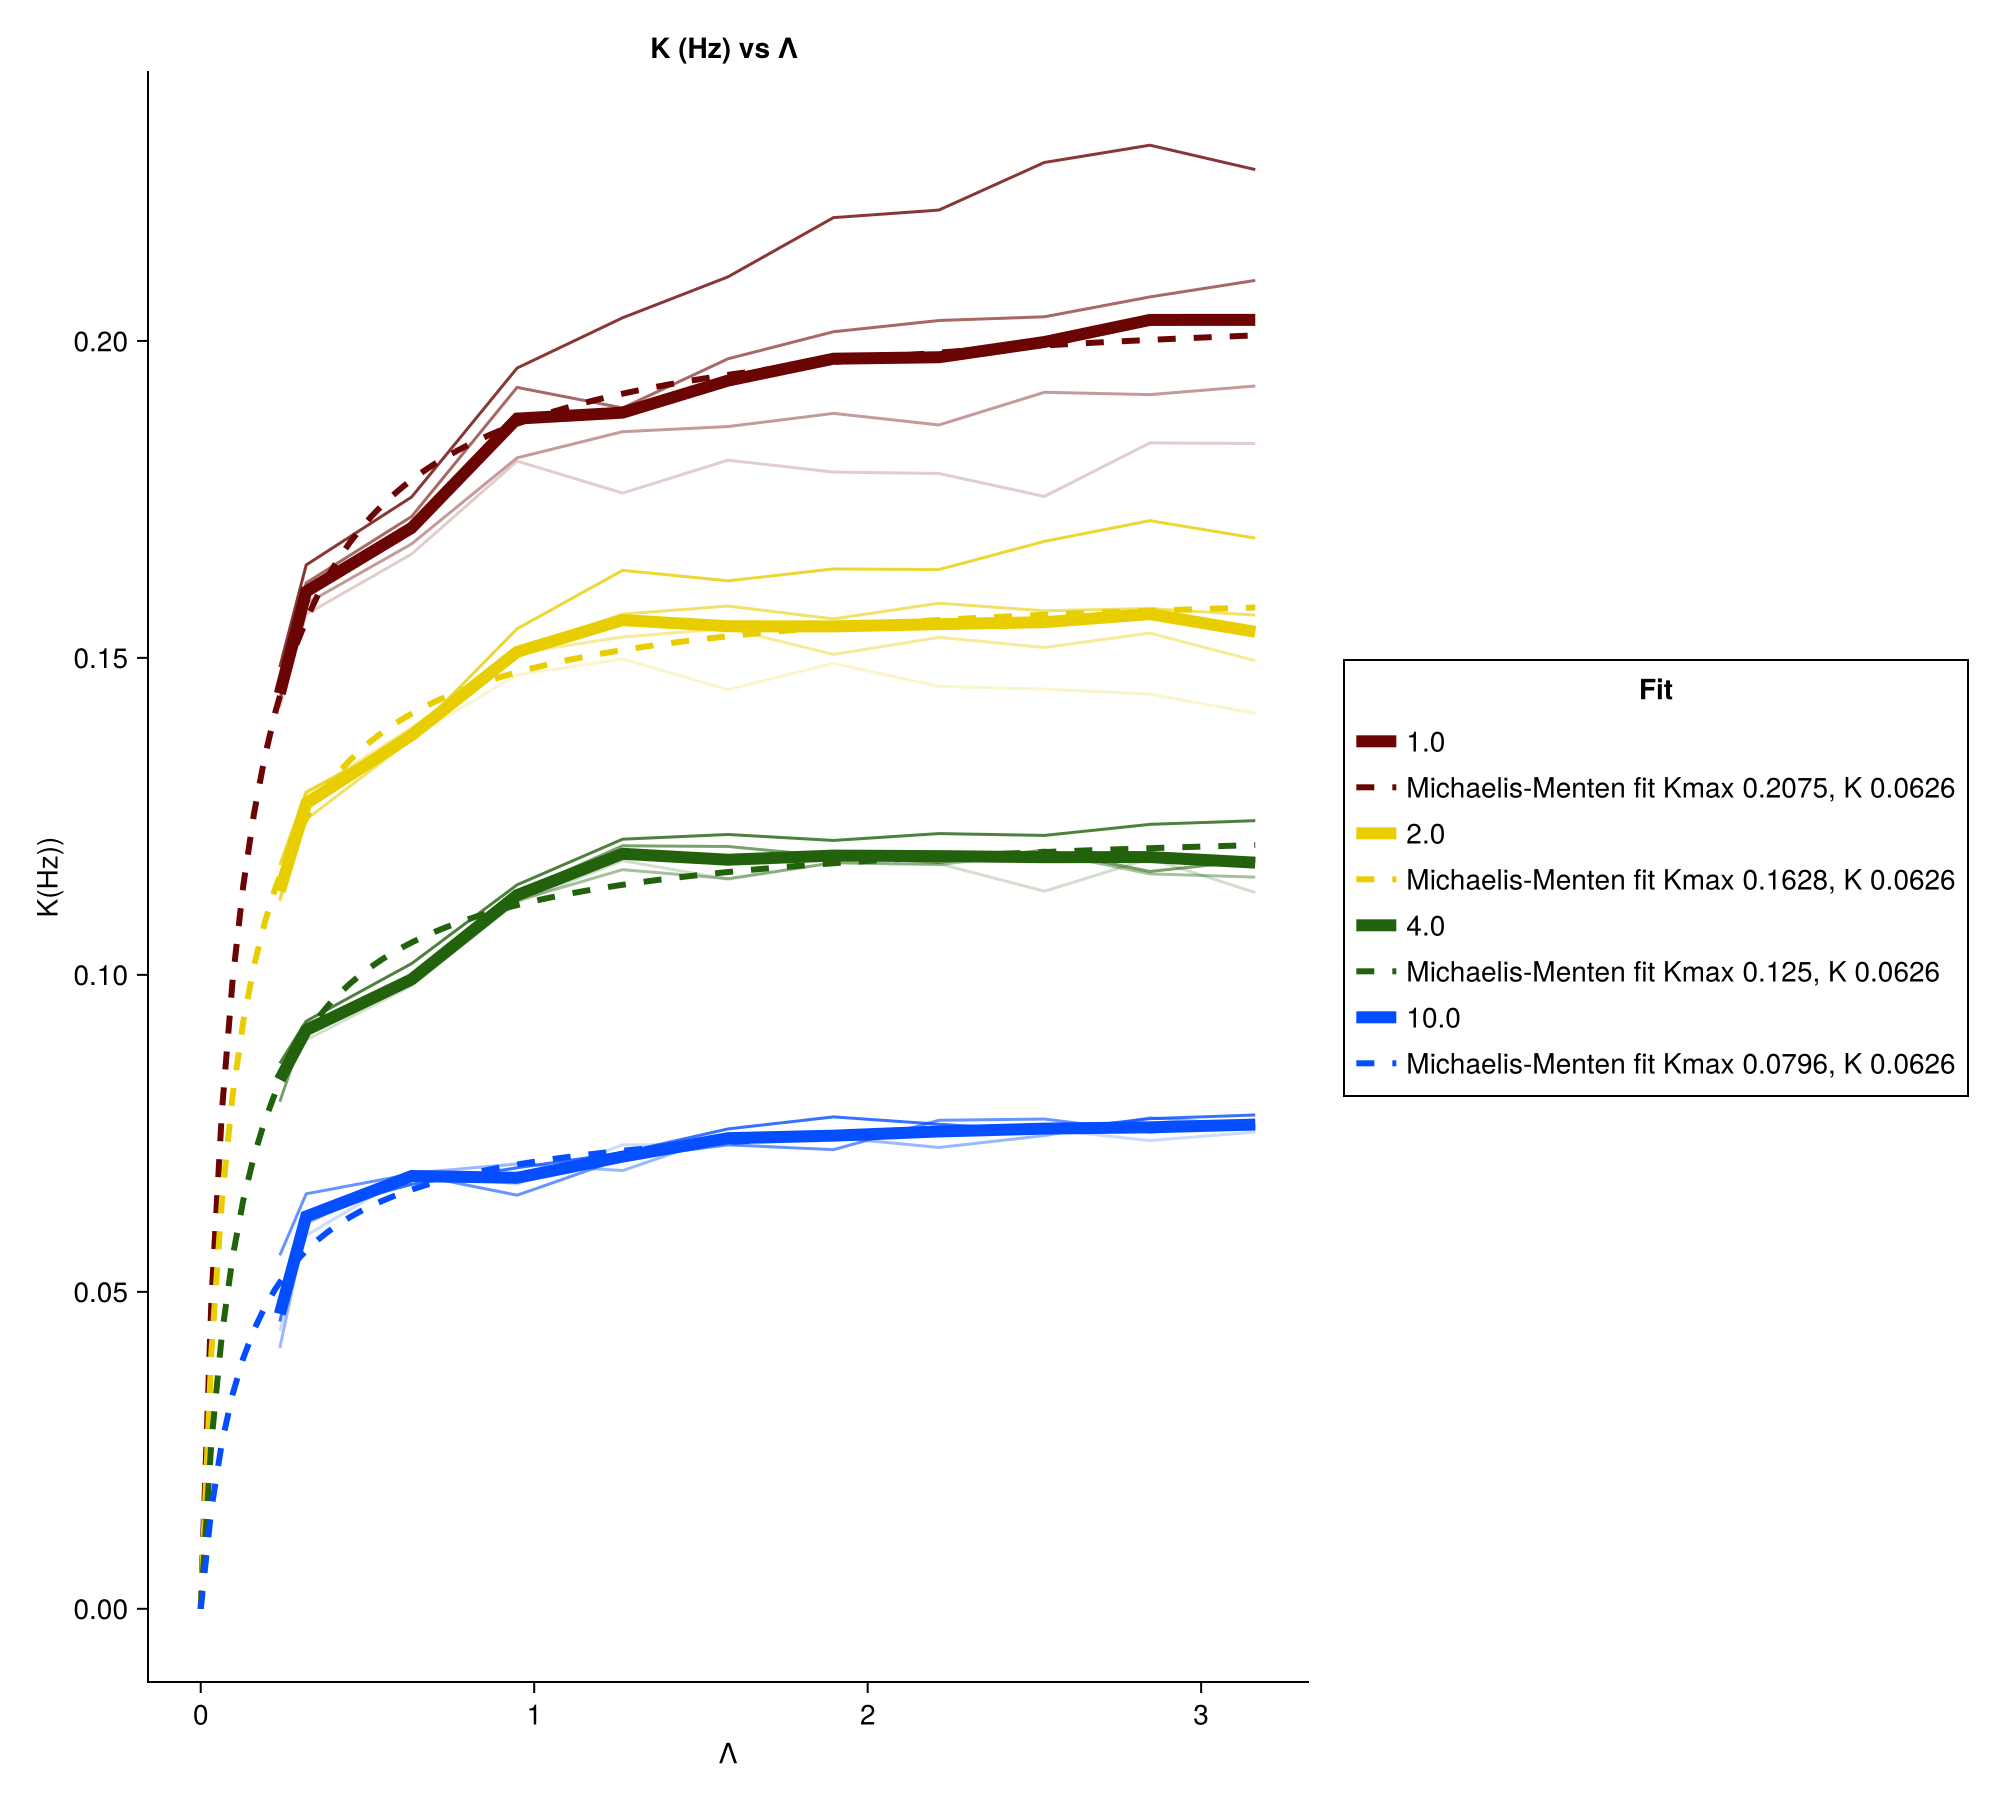

In [53]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]
lambdas = [0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
# lambdas = [0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

# tms = [1.0, 2.0, 4.0]
tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (1000, 900))
ax_k = CairoMakie.Axis(fig[1,1], title = "K (Hz) vs Λ ", xlabel = "Λ", ylabel = "K(Hz))")
# ax_k = CairoMakie.Axis(fig[1,1], title = "Λ vs K", xlabel = "Λ", ylabel = "K (Hz)")
# ax_D = Axis(fig[1,2], title = "Λ vs Variance", xlabel = "Λ", ylabel = L"Variance ($\mu m^2$)")
# ax_D = Axis(fig[1,2], title = "Λ vs D", xlabel = "Λ", ylabel = L"D ($\frac{\mu m^2}{s}$)")
# ax_P = Axis(fig[1,1], title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ", xlabel = L"log($\Lambda$)", ylabel = L"log (P(esc) $\sqrt{\tau _m}$)")
# ax_P = CairoMakie.Axis(fig[1,1], title = "K (Hz) vs Λ ", xlabel = "Λ", ylabel = "K(Hz))")
lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]
# mean_P_tm = zeros(4, 11)
# mean_Ptm = Float64[]

for (idx_t, tm) in enumerate(tms)
        mean_tms_k = zeros(4, 12)
        # mean_tms_D = zeros(4, 11)
        # mean_tms_P = zeros(4, 11)


    for (idx_v, v) in enumerate(vel)
        k_v = []
        D_v = []
        P_v = []
        v_l = []


        for (idx_l, l) in enumerate(lambdas)
        
            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            # filter_1 = dc_delta_all[dc_delta_all.tm .== tm, :]
            # filter_2 = filter_1[filter_1.v .== v, :]
            # row2 = filter_2[filter_2.n .== l, :]

            # field = row2.l[1]
            k = row.k[1]
            # D = row.D[1]
            # P_esc = row.P_esc[1]
            # vl = v / field

            push!(k_v, k)
            # push!(D_v, D)
            # push!(P_v, P_esc)
            # push!(v_l, field)

        end
       
        mean_tms_k[idx_v, :] = k_v
        # mean_tms_D[idx_v, :] = D_v
        # mean_tms_P[idx_v, :] = P_v



        lines!(ax_k, lambdas_x[1:11] ,k_v[1:11], color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P,range(-0.5,1),range(-0.5,1), label ="m=1", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_k, lambdas_x, k_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_D, lambdas_x, D_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        # lines!(ax_P, lambdas_x, P_v, label ="$v", color = (colors[idx_t], intensity[idx_v]))
        
        

    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        # push!(mean_D, mean(mean_tms_D[:, i]))
        # push!(mean_P, mean(mean_tms_P[:, i]))
        
    end

    lines!(ax_k, lambdas_x[1:11], mean_k[1:11], linewidth = 6, label ="$tm", color = colors[idx_t])
    mm_model(x, p) = p[1] .* x ./ (p[2] .+ x)
    # p[1] = kmax
    # p[2] = K
    xdata = Float64.(lambdas_x[1:11])
    ydata = Float64.(mean_k[1:11])
    p0 = [
        maximum(ydata),   # kmax guess
        median(xdata)     # K guess
    ]

    fit = curve_fit(mm_model, xdata, ydata, p0)

    p = fit.param
    kmax = p[1]
    K = 0.0626

    xfit = range(0, maximum(xdata), length=100)
    # xfit = range(0, maximum(xdata), length=100)
    yfit = mm_model(xfit, p)
    lines!(ax_k, xfit, yfit, linewidth=3, label="Michaelis-Menten fit Kmax $(round(kmax, digits=4)), K $(round(K, digits=4))", linestyle =:dash, color = colors[idx_t])
    # # lines!(ax_D, lambdas_x, mean_D, linewidth = 6, label ="$tm", color = colors[idx_t])
    # # lines!(ax_P, lambdas_x, mean_P, linewidth = 6, label ="$tm", color = colors[idx_t])
    
    # slope, intercept = linear_fit(log.(lambdas_x[3:14]), log.(mean_P[3:14]))
    # lines!(ax_P, log.(lambdas_x[3:14]), intercept .+  log.(lambdas_x[3:14]) .* slope, linestyle = :dash, color = :red, label = "$slope")
end  

ax_k.topspinevisible = false
ax_k.rightspinevisible = false
ax_k.ygridvisible = false
ax_k.xgridvisible = false

# ax_D.topspinevisible = false
# ax_D.rightspinevisible = false
# ax_D.ygridvisible = false
# ax_D.xgridvisible = false

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_k, "Fit") # ?

fig            

In [54]:
save("Plots/Fixed_source_model/Next/All/log_P_esc_log_Lambda_michaelis_fit_grid_5.pdf", fig)

CairoMakie.Screen{PDF}


In [59]:
length(lambdas)

13

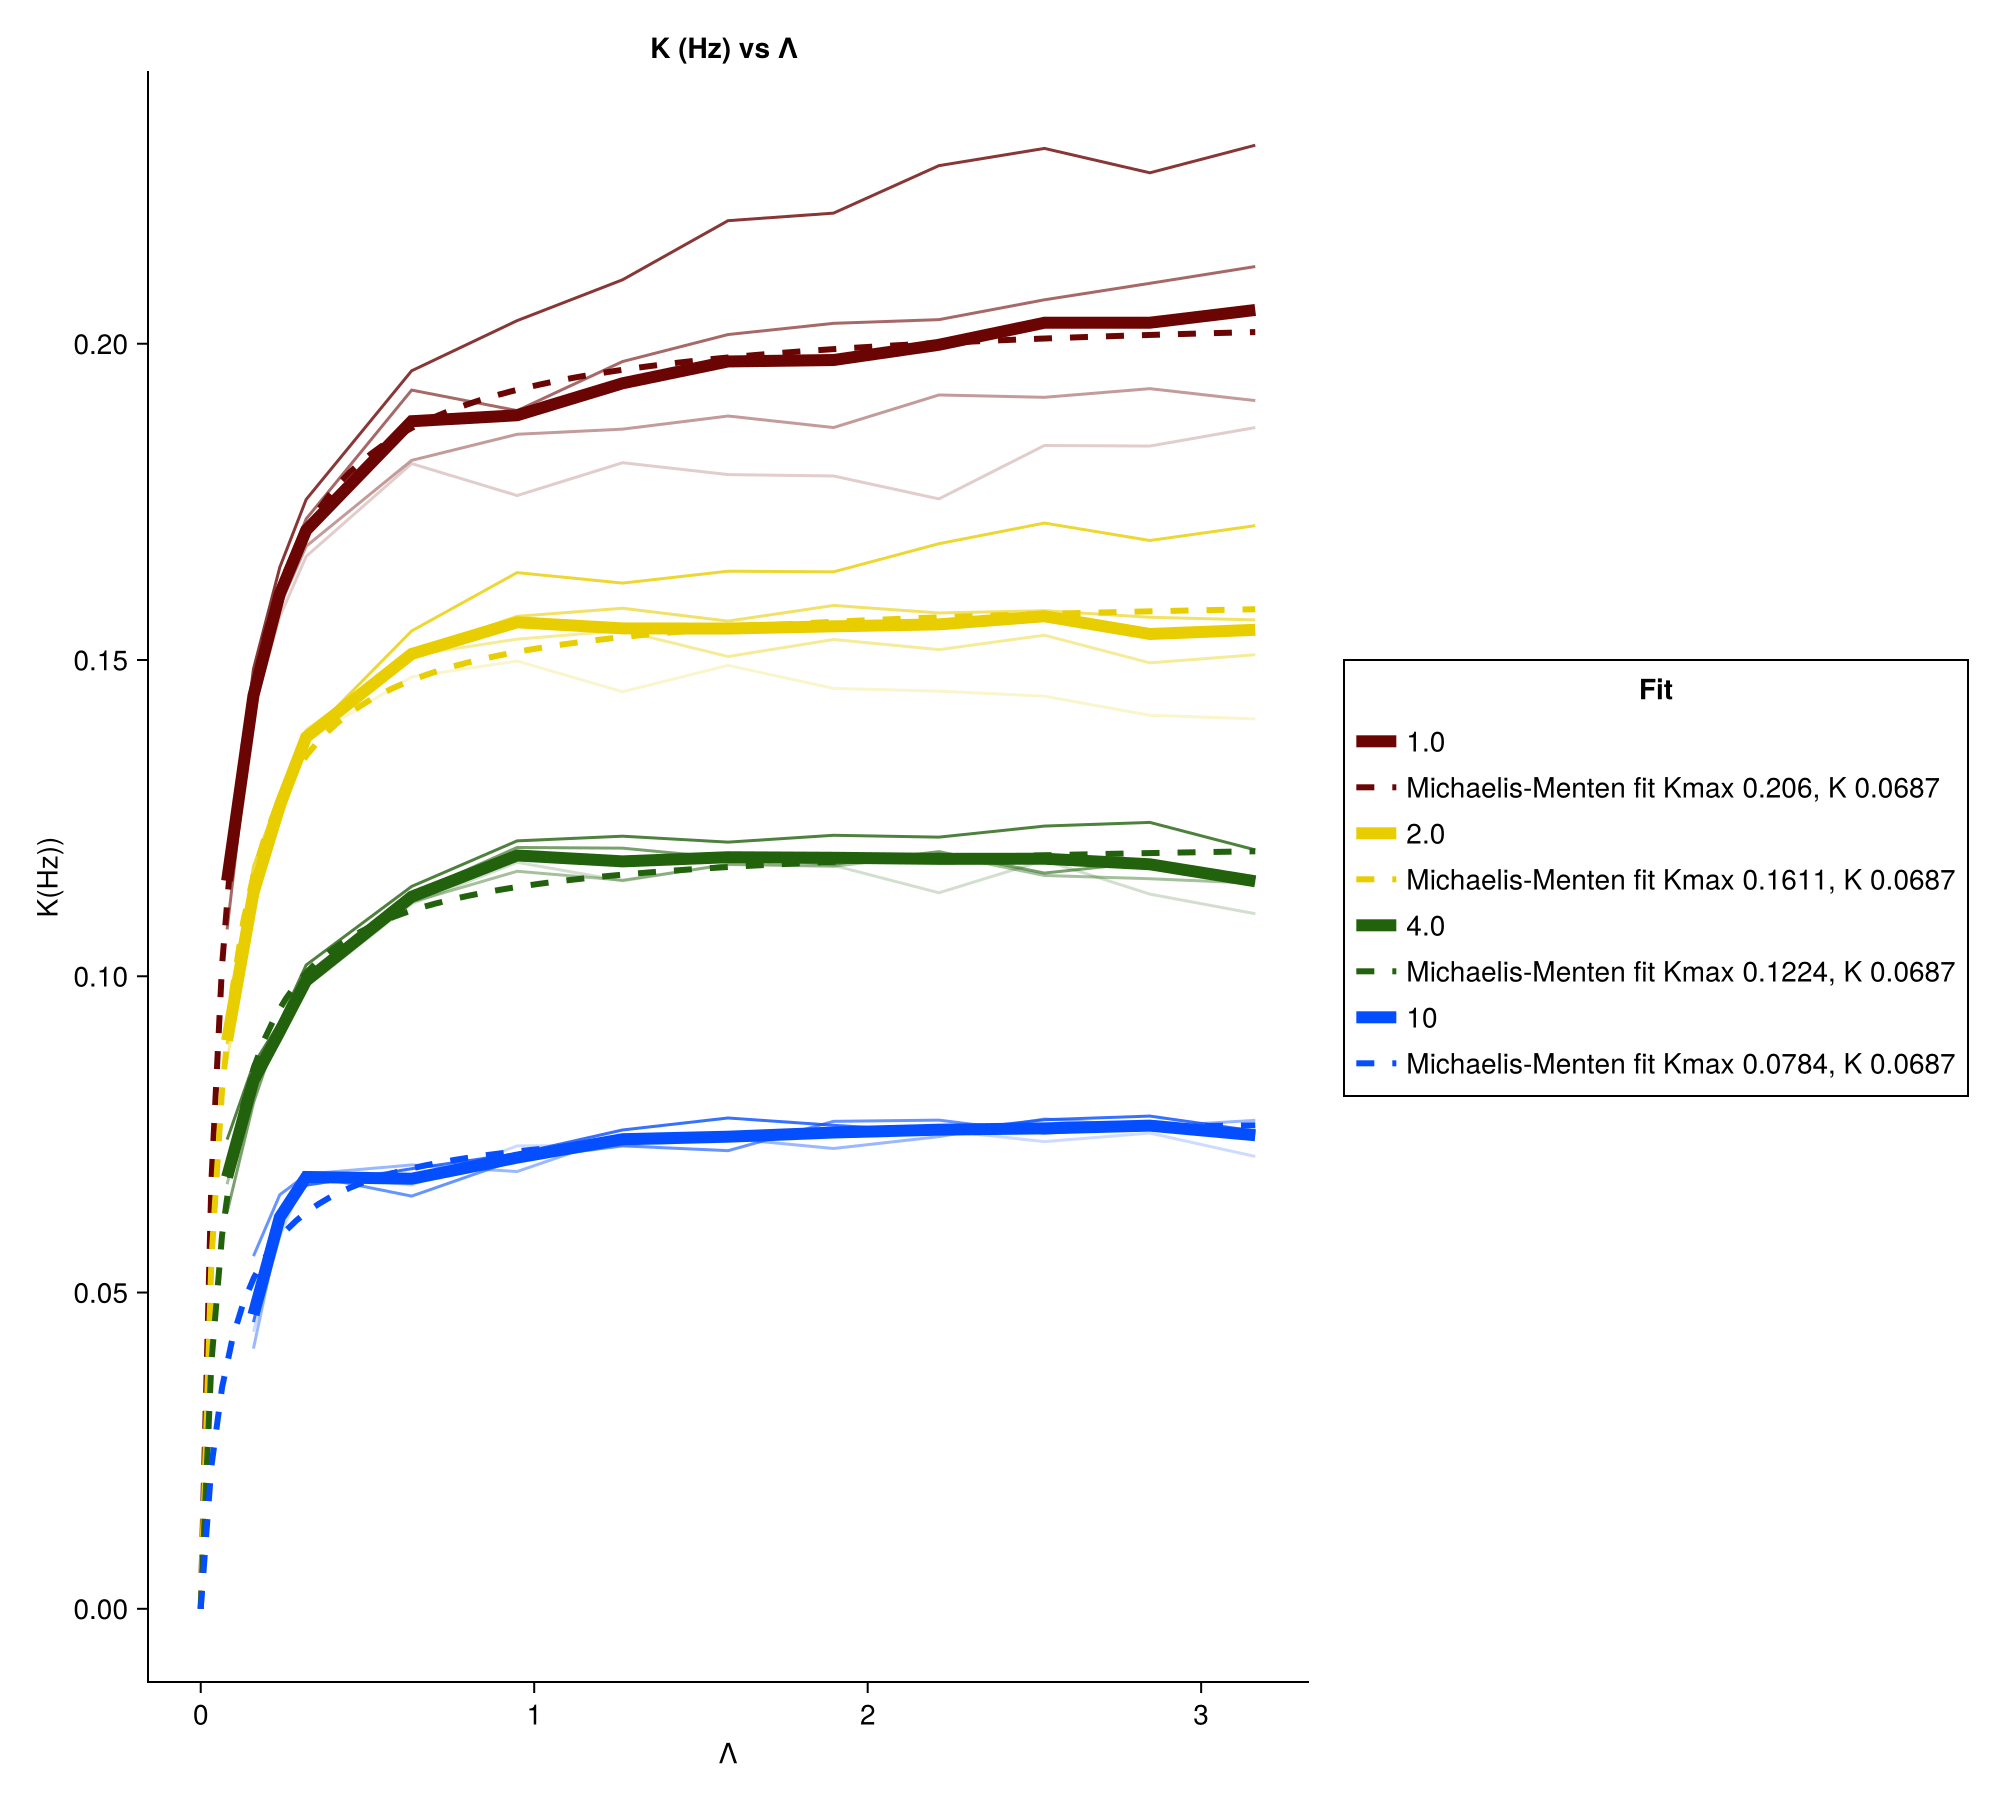

In [74]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


tms = [1.0, 2.0, 4.0]
# tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (1000, 900))
ax_k = CairoMakie.Axis(fig[1,1], title = "K (Hz) vs Λ ", xlabel = "Λ", ylabel = "K(Hz))")
# ax_k = CairoMakie.Axis(fig[1,1], title = "Λ vs K", xlabel = "Λ", ylabel = "K (Hz)")
# ax_D = Axis(fig[1,2], title = "Λ vs Variance", xlabel = "Λ", ylabel = L"Variance ($\mu m^2$)")
# ax_D = Axis(fig[1,2], title = "Λ vs D", xlabel = "Λ", ylabel = L"D ($\frac{\mu m^2}{s}$)")
# ax_P = Axis(fig[1,1], title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ", xlabel = L"log($\Lambda$)", ylabel = L"log (P(esc) $\sqrt{\tau _m}$)")
# ax_P = CairoMakie.Axis(fig[1,1], title = "K (Hz) vs Λ ", xlabel = "Λ", ylabel = "K(Hz))")
lambdas_x = real_lambdas

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]
# mean_P_tm = zeros(4, 11)
# mean_Ptm = Float64[]

for (idx_t, tm) in enumerate(tms)
        mean_tms_k = zeros(4, 13)


    for (idx_v, v) in enumerate(vel)
        k_v = []
        D_v = []
        P_v = []
        v_l = []


        for (idx_l, l) in enumerate(lambdas)
        
            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]

            push!(k_v, k)

        end
       
        mean_tms_k[idx_v, :] = k_v

        lines!(ax_k, lambdas_x ,k_v, color = (colors[idx_t], intensity[idx_v]))  
  
    end

    mean_k = []
  

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
     
        
    end

    lines!(ax_k, lambdas_x, mean_k, linewidth = 6, label ="$tm", color = colors[idx_t])
    mm_model(x, p) = p[1] .* x ./ (p[2] .+ x)

    xdata = Float64.(lambdas_x)
    ydata = Float64.(mean_k)
    p0 = [
        maximum(ydata),   # kmax guess
        median(xdata)     # K guess
    ]

    fit = curve_fit(mm_model, xdata, ydata, p0)

    p = fit.param
    kmax = p[1]
    # K = p[2]
    K = 0.0687

    xfit = range(0, maximum(xdata), length=100)
    yfit = mm_model(xfit, p)
    lines!(ax_k, xfit, yfit, linewidth=3, label="Michaelis-Menten fit Kmax $(round(kmax, digits=4)), K $(round(K, digits=4))", linestyle =:dash, color = colors[idx_t])

end  



mean_tms_k = zeros(4, 12)
lambdas2 = lambdas[2:13]

for (idx_v, v) in enumerate(vel)
        k_v = []
   
    for (idx_l, l) in enumerate(lambdas2)
        
            df = dfs_all[(10.0, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== 10.0, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]

            push!(k_v, k)

    end
       
        mean_tms_k[idx_v, :] = k_v
        lines!(ax_k, lambdas_x[2:13] ,k_v, color = (colors[4], intensity[idx_v]))  
  
end

mean_k = []
  

for i in 1:length(lambdas2)
    push!(mean_k, mean(mean_tms_k[:, i]))
     
end

    lines!(ax_k, lambdas_x[2:13], mean_k, linewidth = 6, label ="10", color = colors[4])
    mm_model(x, p) = p[1] .* x ./ (p[2] .+ x)

    xdata = Float64.(lambdas_x[2:13])
    ydata = Float64.(mean_k)
    p0 = [
        maximum(ydata),   # kmax guess
        median(xdata)     # K guess
    ]

    fit = curve_fit(mm_model, xdata, ydata, p0)

    p = fit.param
    kmax = p[1]
    # K = p[2]
    K = 0.0687

    xfit = range(0, maximum(xdata), length=100)
    yfit = mm_model(xfit, p)
    lines!(ax_k, xfit, yfit, linewidth=3, label="Michaelis-Menten fit Kmax $(round(kmax, digits=4)), K $(round(K, digits=4))", linestyle =:dash, color = colors[4])



ax_k.topspinevisible = false
ax_k.rightspinevisible = false
ax_k.ygridvisible = false
ax_k.xgridvisible = false

# ax_D.topspinevisible = false
# ax_D.rightspinevisible = false
# ax_D.ygridvisible = false
# ax_D.xgridvisible = false

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_k, "Fit") # ?

fig            

In [75]:
save("Plots/Fixed_source_model/Next/All/log_P_esc_log_Lambda_michaelis_fit_grid_6.pdf", fig)

CairoMakie.Screen{PDF}


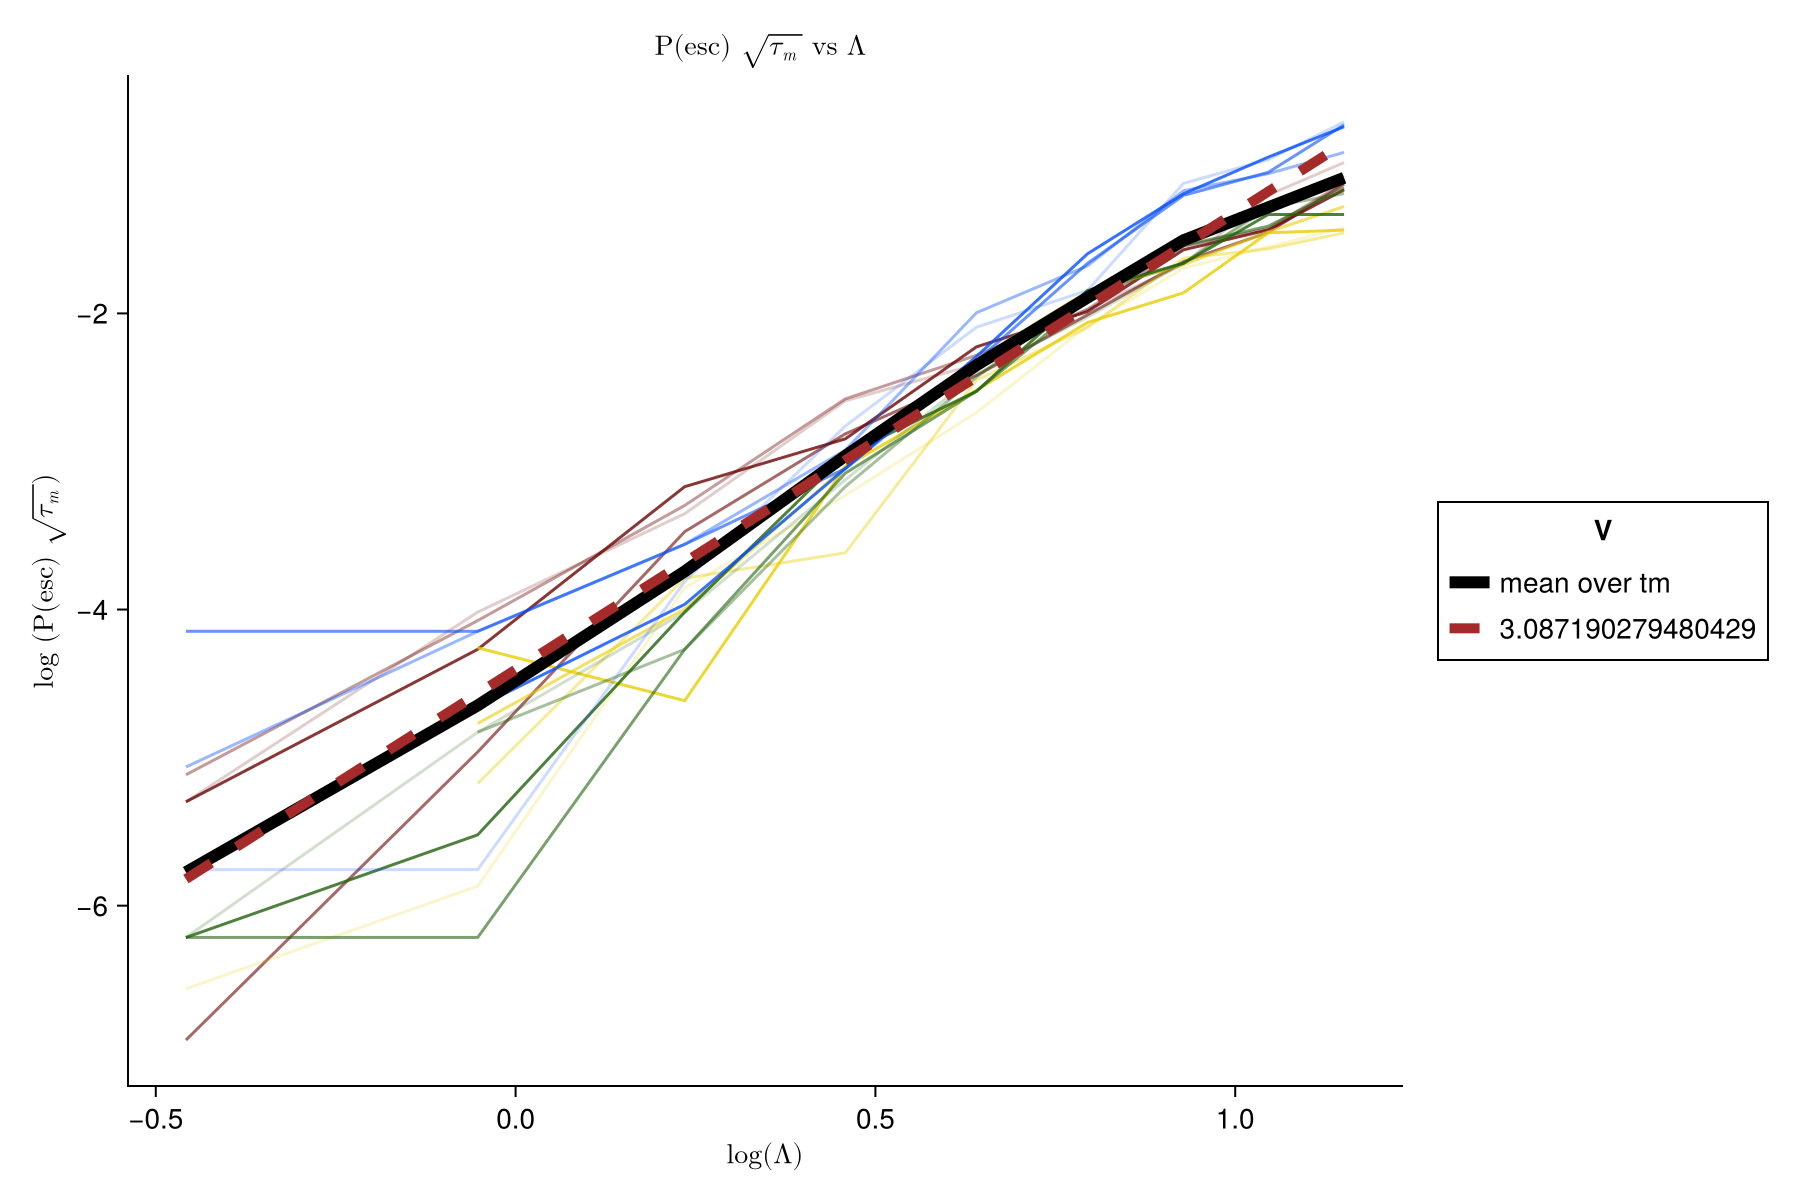

In [28]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))

ax_P = Axis(
    fig[1,1],
    title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ",
    xlabel = L"log($\Lambda$)",
    ylabel = L"log (P(esc) $\sqrt{\tau _m}$)"
)

lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]

mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

# Store the mean_P .* sqrt(tm) curves for each tm
all_mean_P = zeros(length(tms), length(lambdas))

for (idx_t, tm) in enumerate(tms)

    mean_tms_k = zeros(4, 14)
    mean_tms_D = zeros(4, 14)
    mean_tms_P = zeros(4, 14)

    for (idx_v, v) in enumerate(vel)

        k_v = []
        D_v = []
        P_v = []

        for (idx_l, l) in enumerate(lambdas)

            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]
            D = row.D[1]
            P_esc = row.P_esc[1]

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
        end

        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v

        lines!(
            ax_P,
            log.(lambdas_x[3:11]),
            log.(P_v[3:11] .* sqrt(tm)),
            color = (colors[idx_t], intensity[idx_v])
        )
    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        push!(mean_D, mean(mean_tms_D[:, i]))
        push!(mean_P, mean(mean_tms_P[:, i]))
    end

    # Store the same quantity that is plotted: mean_P * sqrt(tm)
    all_mean_P[idx_t, :] = mean_P .* sqrt(tm)

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm)),
    #     linewidth = 6,
    #     label = "$tm",
    #     color = colors[idx_t]
    # )

    # slope, intercept = linear_fit(
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm))
    # )

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     intercept .+ log.(lambdas_x[3:14]) .* slope,
    #     linestyle = :dash,
    #     color = :red,
    #     label = "$slope"
    # )
end

# Mean over all tm values
grand_mean_P = vec(mean(all_mean_P, dims = 1))
slope1, intercept1 = linear_fit(log.(lambdas_x[11:14]), log.(grand_mean_P[11:14]))
slope2, intercept2 = linear_fit(log.(lambdas_x[3:10]), log.(grand_mean_P[3:10]))
lines!(
    ax_P,
    log.(lambdas_x[3:11]),
    log.(grand_mean_P[3:11]),
    linewidth = 6,
    color = :black,
    label = "mean over tm"
)

# lines!(
#     ax_P,
#     log.(lambdas_x[3:11]),
#     intercept1 .+ log.(lambdas_x[3:11]) .* slope1,
#     linewidth = 5,
#     color = :red,
#     linestyle = :dash,
#     label = "$slope1"
# )

lines!(
    ax_P,
    log.(lambdas_x[3:11]),
    intercept2 .+ log.(lambdas_x[3:11]) .* slope2,
    linewidth = 5,
    color = :brown,
    linestyle = :dash,
    label = "$slope2"
)

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_P, "V")

fig

In [29]:
save("Plots/Fixed_source_model/Next/All/log_P_esc_log_Lambda_slope_3.pdf", fig)


CairoMakie.Screen{PDF}


In [39]:
metrics_all

Row,tm,v,l,mu,sigma,variance,k,D,P_esc
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1.0,5.0,0.25,-0.0196157,7.04843,49.6803,0.115707,5.74836,0.005
2,1.0,10.0,0.25,0.0509994,14.2339,202.605,0.107402,21.7602,0.002
3,1.0,20.0,0.25,0.037579,27.9451,780.943,0.118107,92.2352,0.004
4,1.0,100.0,0.25,0.715938,140.168,19647.4,0.119121,2340.42,0.01
5,2.0,5.0,0.25,0.00929017,9.26406,85.823,0.0892695,7.66138,0.02
6,2.0,10.0,0.25,0.197182,18.5718,344.923,0.092583,31.934,0.005
7,2.0,20.0,0.25,-0.0761863,37.3084,1391.92,0.0866209,120.569,0.01
8,2.0,100.0,0.25,1.2922,183.589,33704.9,0.0908656,3062.62,0.019
9,4.0,5.0,0.25,0.589631,14.6605,214.955,0.0741803,15.9454,0.407


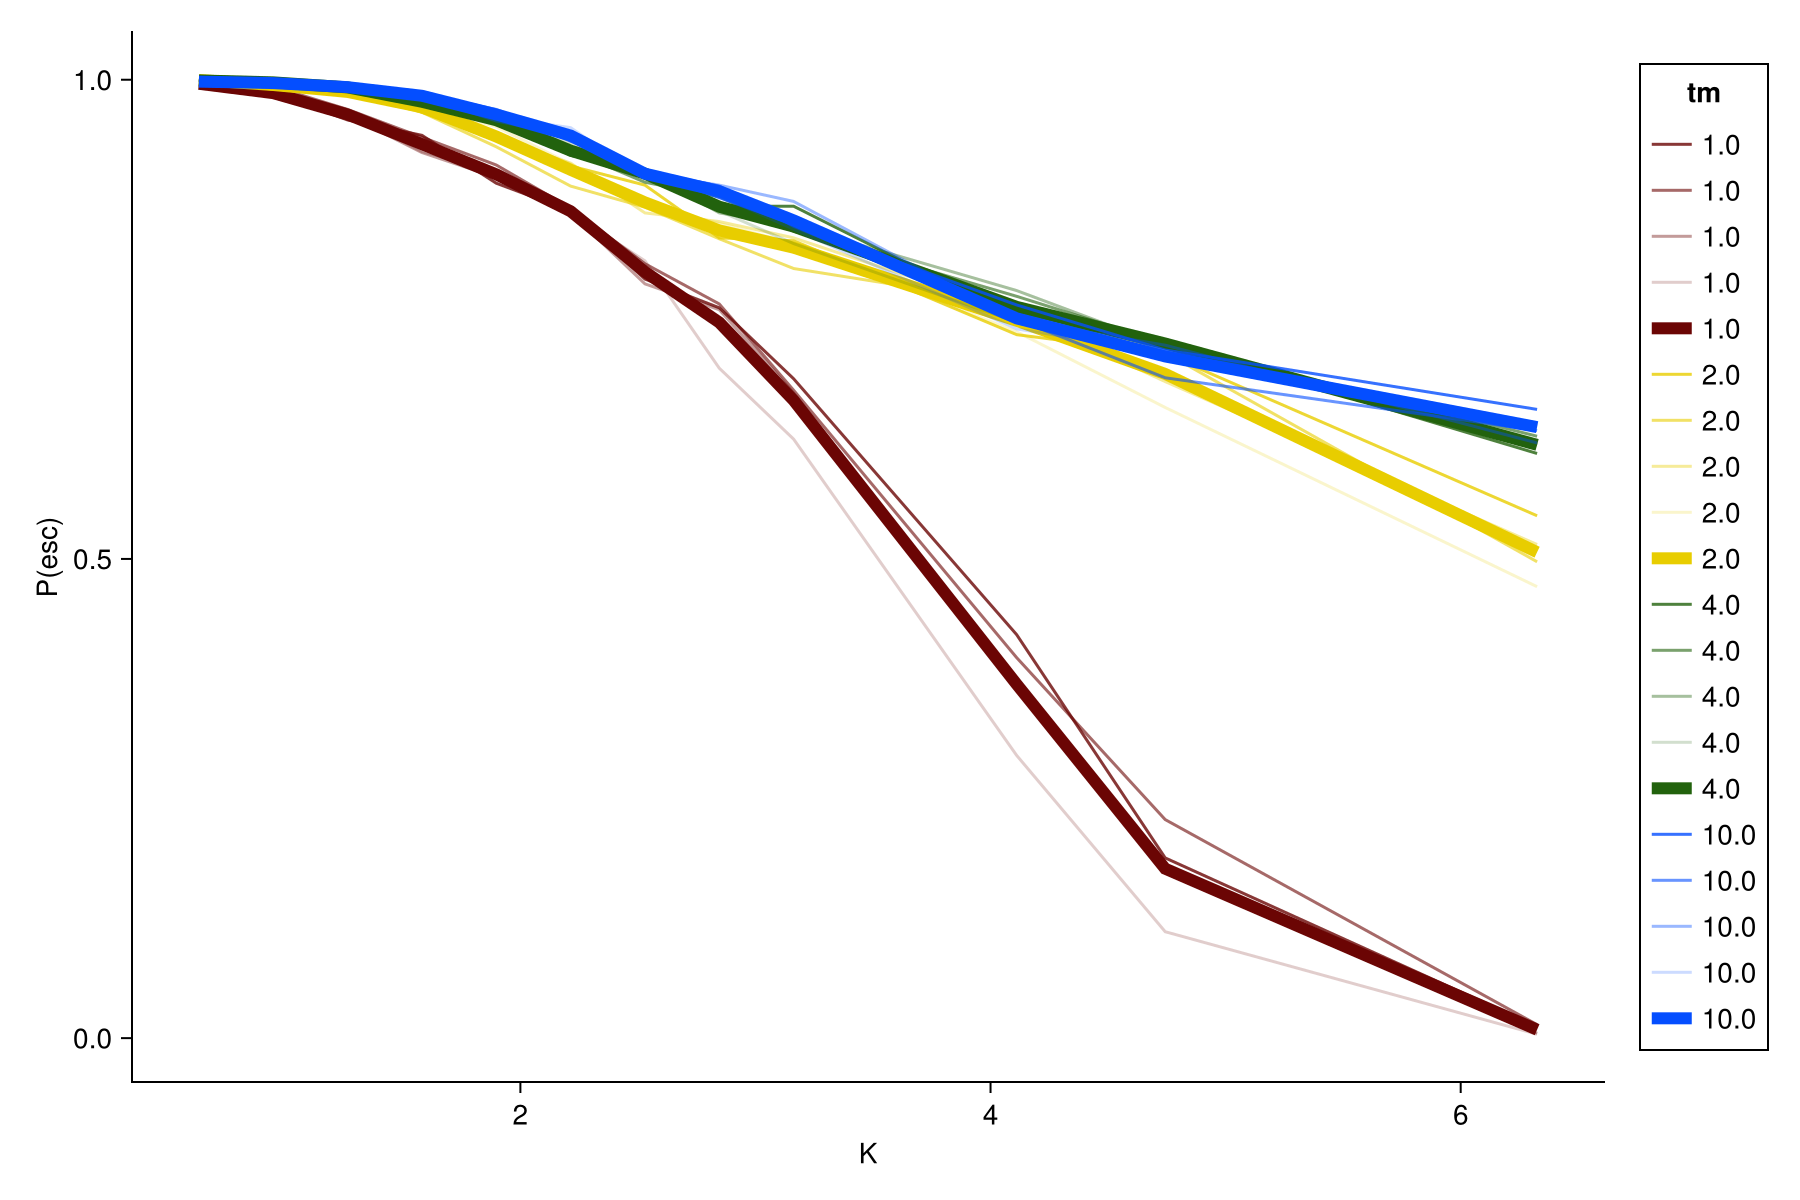

In [22]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))

# ax_P = Axis(
#     fig[1,1],
#     title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ",
#     xlabel = L"log($\Lambda$)",
#     ylabel = L"log (P(esc) $\sqrt{\tau _m}$)"
# )
ax_P = Axis(
    fig[1,1],
    title = "",
    xlabel = "K",
    ylabel = "P(esc)"
)

lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
intensity = [0.8, 0.6, 0.4, 0.2]

mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

# Store the mean_P .* sqrt(tm) curves for each tm
all_mean_P = zeros(length(tms), length(lambdas))

for (idx_t, tm) in enumerate(tms)

    mean_tms_k = zeros(4, 14)
    mean_tms_D = zeros(4, 14)
    mean_tms_P = zeros(4, 14)

    for (idx_v, v) in enumerate(vel)

        k_v = []
        D_v = []
        P_v = []

        for (idx_l, l) in enumerate(lambdas)

            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]
            D = row.D[1]
            P_esc = 1 - row.P_esc[1]

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
        end

        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v

        lines!(
            ax_P,
            (lambdas_x[3:14]),
            (P_v[3:14]),
            color = (colors[idx_t], intensity[idx_v]), 
            label ="$tm"
        )
    end

    mean_k = []
    mean_D = []
    mean_P = []

    for i in 1:length(lambdas)
        push!(mean_k, mean(mean_tms_k[:, i]))
        push!(mean_D, mean(mean_tms_D[:, i]))
        push!(mean_P, mean(mean_tms_P[:, i]))
    end

    # # Store the same quantity that is plotted: mean_P * sqrt(tm)
    # all_mean_P[idx_t, :] = mean_P .* sqrt(tm)

    lines!(
        ax_P,
        (lambdas_x[3:14]),
        (mean_P[3:14]),
        linewidth = 6,
        label = "$tm",
        color = colors[idx_t]
    )

    # slope, intercept = linear_fit(
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm))
    # )

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     intercept .+ log.(lambdas_x[3:14]) .* slope,
    #     linestyle = :dash,
    #     color = :red,
    #     label = "$slope"
    # )
end

# Mean over all tm values
# grand_mean_P = vec(mean(all_mean_P, dims = 1))
# slope1, intercept1 = linear_fit(log.(lambdas_x[11:14]), log.(grand_mean_P[11:14]))
# slope2, intercept2 = linear_fit(log.(lambdas_x[3:10]), log.(grand_mean_P[3:10]))
# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     log.(grand_mean_P[3:14]),
#     linewidth = 6,
#     color = :black,
#     label = "mean over tm"
# )

# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     intercept1 .+ log.(lambdas_x[3:14]) .* slope1,
#     linewidth = 5,
#     color = :red,
#     linestyle = :dash,
#     label = "$slope1"
# )

# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     intercept2 .+ log.(lambdas_x[3:14]) .* slope2,
#     linewidth = 5,
#     color = :brown,
#     linestyle = :dash,
#     label = "$slope2"
# )

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_P, "tm")

fig

In [23]:
save("Plots/Fixed_source_model/Next/All/P_trap_n50.pdf", fig)

CairoMakie.Screen{PDF}


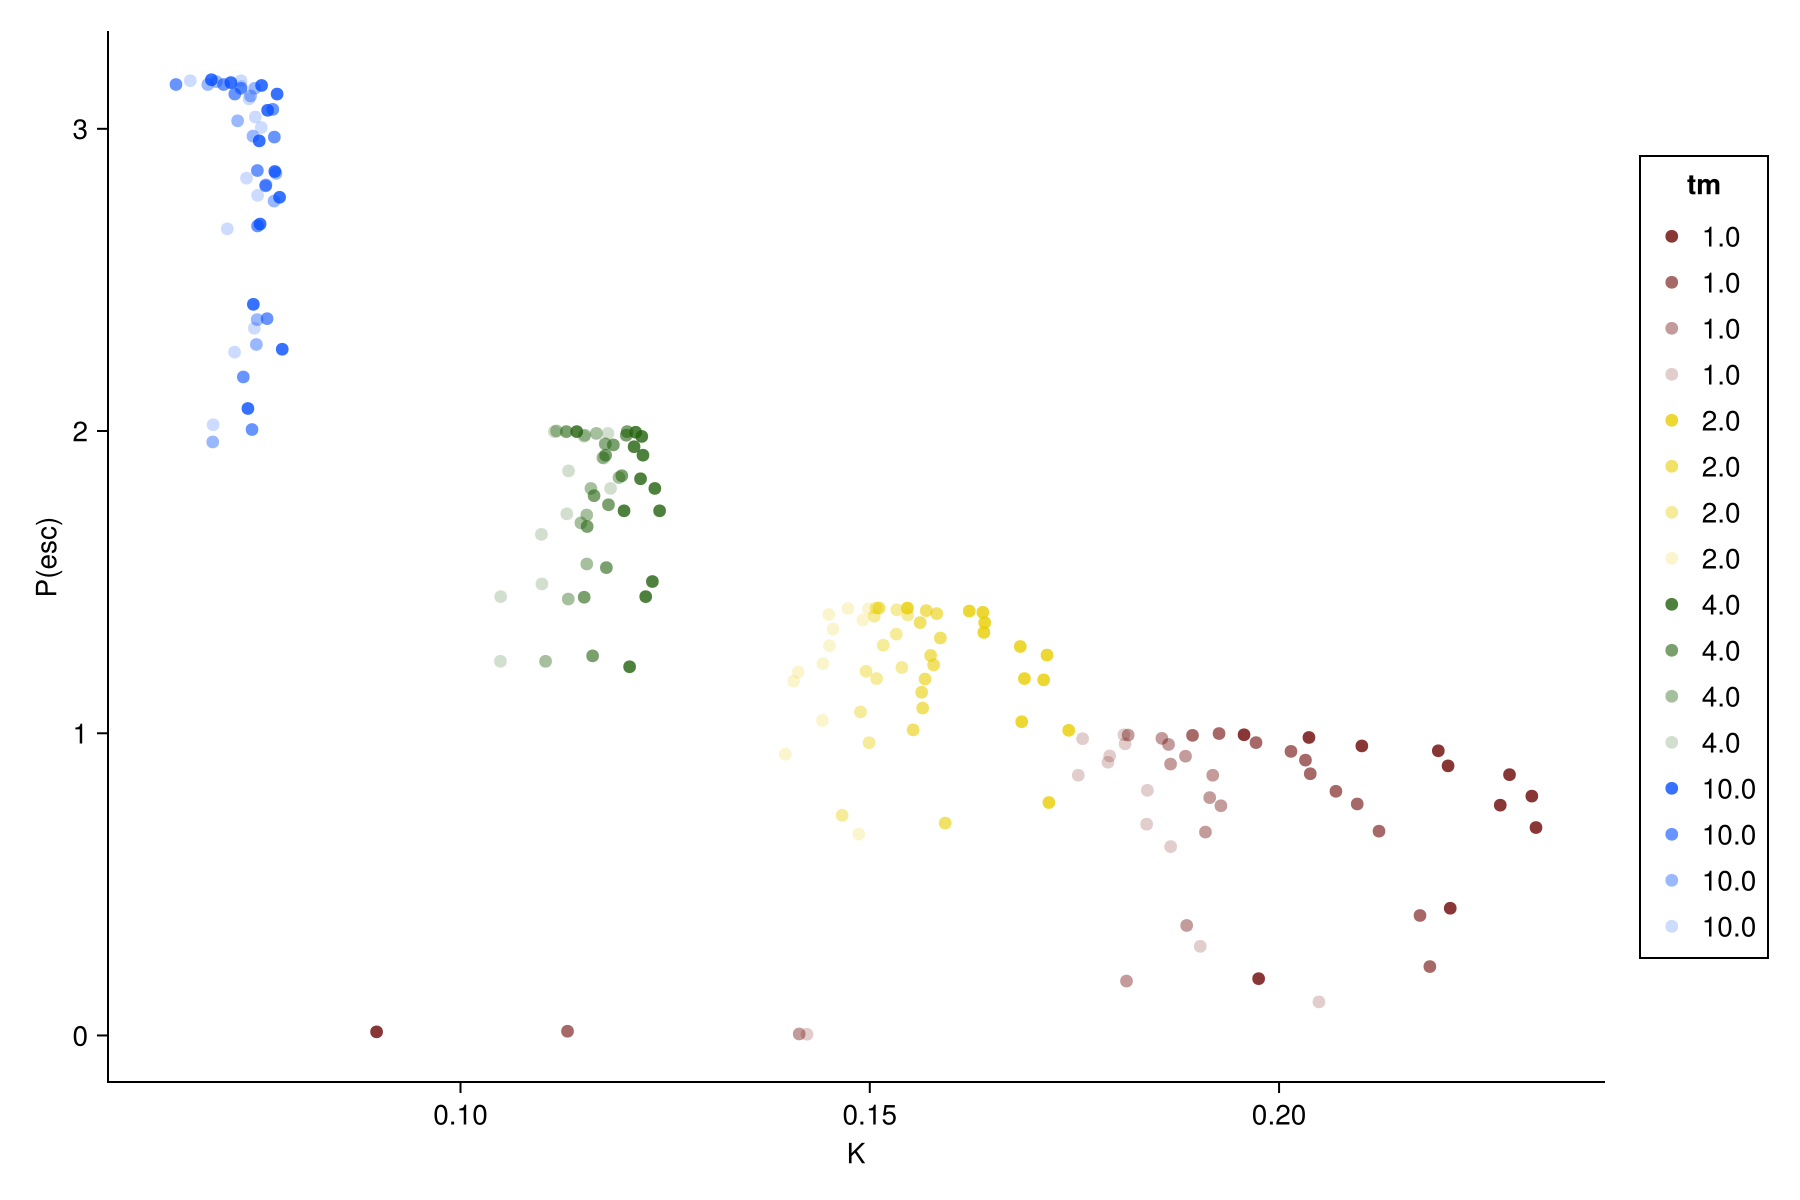

In [65]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
# lambdas = [4.0]
lambdas = [0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))

# ax_P = Axis(
#     fig[1,1],
#     title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ",
#     xlabel = L"log($\Lambda$)",
#     ylabel = L"log (P(esc) $\sqrt{\tau _m}$)"
# )
ax_P = Axis(
    fig[1,1],
    title = "",
    xlabel = "K",
    ylabel = "P(esc)"
)

lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c] 
intensity = [0.8, 0.6, 0.4, 0.2]

mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

# Store the mean_P .* sqrt(tm) curves for each tm
all_mean_P = zeros(length(tms), length(lambdas))

for (idx_t, tm) in enumerate(tms)

    mean_tms_k = zeros(4, 14)
    mean_tms_D = zeros(4, 14)
    mean_tms_P = zeros(4, 14)
    # mean_tms_k = zeros(4, 1)
    # mean_tms_D = zeros(4, 1)
    # mean_tms_P = zeros(4, 1)
    for (idx_v, v) in enumerate(vel)


        k_v = []
        D_v = []
        P_v = []

        
        for (idx_l, l) in enumerate(lambdas)

            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]
            D = row.D[1]
            P_esc = 1 - row.P_esc[1]

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
        end

        mean_tms_k[idx_v, :] = k_v
        mean_tms_D[idx_v, :] = D_v
        mean_tms_P[idx_v, :] = P_v

        scatter!(
            ax_P,
            (k_v[3:14]),
            (P_v[3:14].* sqrt(tm)) ,
            color = (colors[idx_t], intensity[idx_v]), 
            label ="$tm"
        )
    end

    mean_k = []
    mean_D = []
    mean_P = []

    # for i in 1:length(lambdas)
    #     push!(mean_k, mean(mean_tms_k[:, i]))
    #     push!(mean_D, mean(mean_tms_D[:, i]))
    #     push!(mean_P, mean(mean_tms_P[:, i]))
    # end

    # # Store the same quantity that is plotted: mean_P * sqrt(tm)
    # all_mean_P[idx_t, :] = mean_P .* sqrt(tm)

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm)),
    #     linewidth = 6,
    #     label = "$tm",
    #     color = colors[idx_t]
    # )

    # slope, intercept = linear_fit(
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm))
    # )

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     intercept .+ log.(lambdas_x[3:14]) .* slope,
    #     linestyle = :dash,
    #     color = :red,
    #     label = "$slope"
    # )
end

# Mean over all tm values
# grand_mean_P = vec(mean(all_mean_P, dims = 1))
# slope1, intercept1 = linear_fit(log.(lambdas_x[11:14]), log.(grand_mean_P[11:14]))
# slope2, intercept2 = linear_fit(log.(lambdas_x[3:10]), log.(grand_mean_P[3:10]))
# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     log.(grand_mean_P[3:14]),
#     linewidth = 6,
#     color = :black,
#     label = "mean over tm"
# )

# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     intercept1 .+ log.(lambdas_x[3:14]) .* slope1,
#     linewidth = 5,
#     color = :red,
#     linestyle = :dash,
#     label = "$slope1"
# )

# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     intercept2 .+ log.(lambdas_x[3:14]) .* slope2,
#     linewidth = 5,
#     color = :brown,
#     linestyle = :dash,
#     label = "$slope2"
# )

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_P, "tm")

fig

In [66]:
save("Plots/Fixed_source_model/Next/All/k_p.pdf", fig)

CairoMakie.Screen{PDF}


In [ ]:
real_lambdas = [0.0790569415, 0.158113883, 0.2371708245, 0.316227766, 0.632455532, 0.9486832981, 1.264911064, 1.58113883, 1.897366596, 2.213594362, 2.529822128, 2.846049894, 3.16227766, 4.111, 4.743, 6.325]
lambdas = [0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 15.0, 20.0]

tms = [1.0, 2.0, 4.0, 10.0]
vel = [5.0, 10.0, 20.0, 100.0]

fig = Figure(size = (900, 600))

# ax_P = Axis(
#     fig[1,1],
#     title = L"P(esc) $\sqrt{\tau _m}$ vs $\Lambda$ ",
#     xlabel = L"log($\Lambda$)",
#     ylabel = L"log (P(esc) $\sqrt{\tau _m}$)"
# )
ax_P = Axis(
    fig[1,1],
    title = "",
    xlabel = "K",
    ylabel = "P(esc)"
)

lambdas_x = real_lambdas[3:end]

tm1_c = colorant"#6B0504"
tm2_c = colorant"#E8CD00"
tm4_c = colorant"#22620D"
tm10_c = colorant"#044EFF"

colors = [tm1_c, tm2_c, tm4_c, tm10_c]
colors = 
intensity = [0.8, 0.6, 0.4, 0.2]

mean_P_tm = zeros(4, 14)
mean_Ptm = Float64[]

# Store the mean_P .* sqrt(tm) curves for each tm
all_mean_P = zeros(length(tms), length(lambdas))

for (idx_t, tm) in enumerate(tms)

    mean_tms_k = zeros(14, 4)
    mean_tms_D = zeros(14, 4)
    mean_tms_P = zeros(14, 4)

    for (idx_l, l) in enumerate(lambdas)


        k_v = []
        D_v = []
        P_v = []

        for (idx_v, v) in enumerate(vel)

            df = dfs_all[(tm, v, l)]

            filter_1 = metrics_all[metrics_all.tm .== tm, :]
            filter_2 = filter_1[filter_1.v .== v, :]
            row = filter_2[filter_2.l .== l, :]

            k = row.k[1]
            D = row.D[1]
            P_esc = 1 - row.P_esc[1]

            push!(k_v, k)
            push!(D_v, D)
            push!(P_v, P_esc)
        end

        mean_tms_k[idx_l, :] = k_v
        mean_tms_D[idx_l, :] = D_v
        mean_tms_P[idx_l, :] = P_v

        scatter!(
            ax_P,
            (k_v),
            (P_v),
            
            label ="$l"
        )
    end

    mean_k = []
    mean_D = []
    mean_P = []

    # for i in 1:length(lambdas)
    #     push!(mean_k, mean(mean_tms_k[:, i]))
    #     push!(mean_D, mean(mean_tms_D[:, i]))
    #     push!(mean_P, mean(mean_tms_P[:, i]))
    # end

    # # Store the same quantity that is plotted: mean_P * sqrt(tm)
    # all_mean_P[idx_t, :] = mean_P .* sqrt(tm)

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm)),
    #     linewidth = 6,
    #     label = "$tm",
    #     color = colors[idx_t]
    # )

    # slope, intercept = linear_fit(
    #     log.(lambdas_x[3:14]),
    #     log.(mean_P[3:14] .* sqrt(tm))
    # )

    # lines!(
    #     ax_P,
    #     log.(lambdas_x[3:14]),
    #     intercept .+ log.(lambdas_x[3:14]) .* slope,
    #     linestyle = :dash,
    #     color = :red,
    #     label = "$slope"
    # )
end

# Mean over all tm values
# grand_mean_P = vec(mean(all_mean_P, dims = 1))
# slope1, intercept1 = linear_fit(log.(lambdas_x[11:14]), log.(grand_mean_P[11:14]))
# slope2, intercept2 = linear_fit(log.(lambdas_x[3:10]), log.(grand_mean_P[3:10]))
# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     log.(grand_mean_P[3:14]),
#     linewidth = 6,
#     color = :black,
#     label = "mean over tm"
# )

# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     intercept1 .+ log.(lambdas_x[3:14]) .* slope1,
#     linewidth = 5,
#     color = :red,
#     linestyle = :dash,
#     label = "$slope1"
# )

# lines!(
#     ax_P,
#     log.(lambdas_x[3:14]),
#     intercept2 .+ log.(lambdas_x[3:14]) .* slope2,
#     linewidth = 5,
#     color = :brown,
#     linestyle = :dash,
#     label = "$slope2"
# )

ax_P.topspinevisible = false
ax_P.rightspinevisible = false
ax_P.ygridvisible = false
ax_P.xgridvisible = false

fig[1,2] = Legend(fig, ax_P, "tm")

fig

In [122]:
sort(metrics_all.D)[1:20]

20-element Vector{Float64}:
 10.62134493294639
 14.398144552666084
 14.875781907571557
 15.555049604149932
 15.557002133980088
 16.43963953278096
 17.027724567745693
 17.61516921516367
 19.282990486204394
 19.88801212321901
 20.85126191668872
 20.916177937322477
 21.154452274914764
 23.359988062312787
 23.720819061042853
 24.69782973131797
 25.873083694687672
 27.3455626105354
 28.402686660583313
 28.42894793621545

# D = v^2 tm

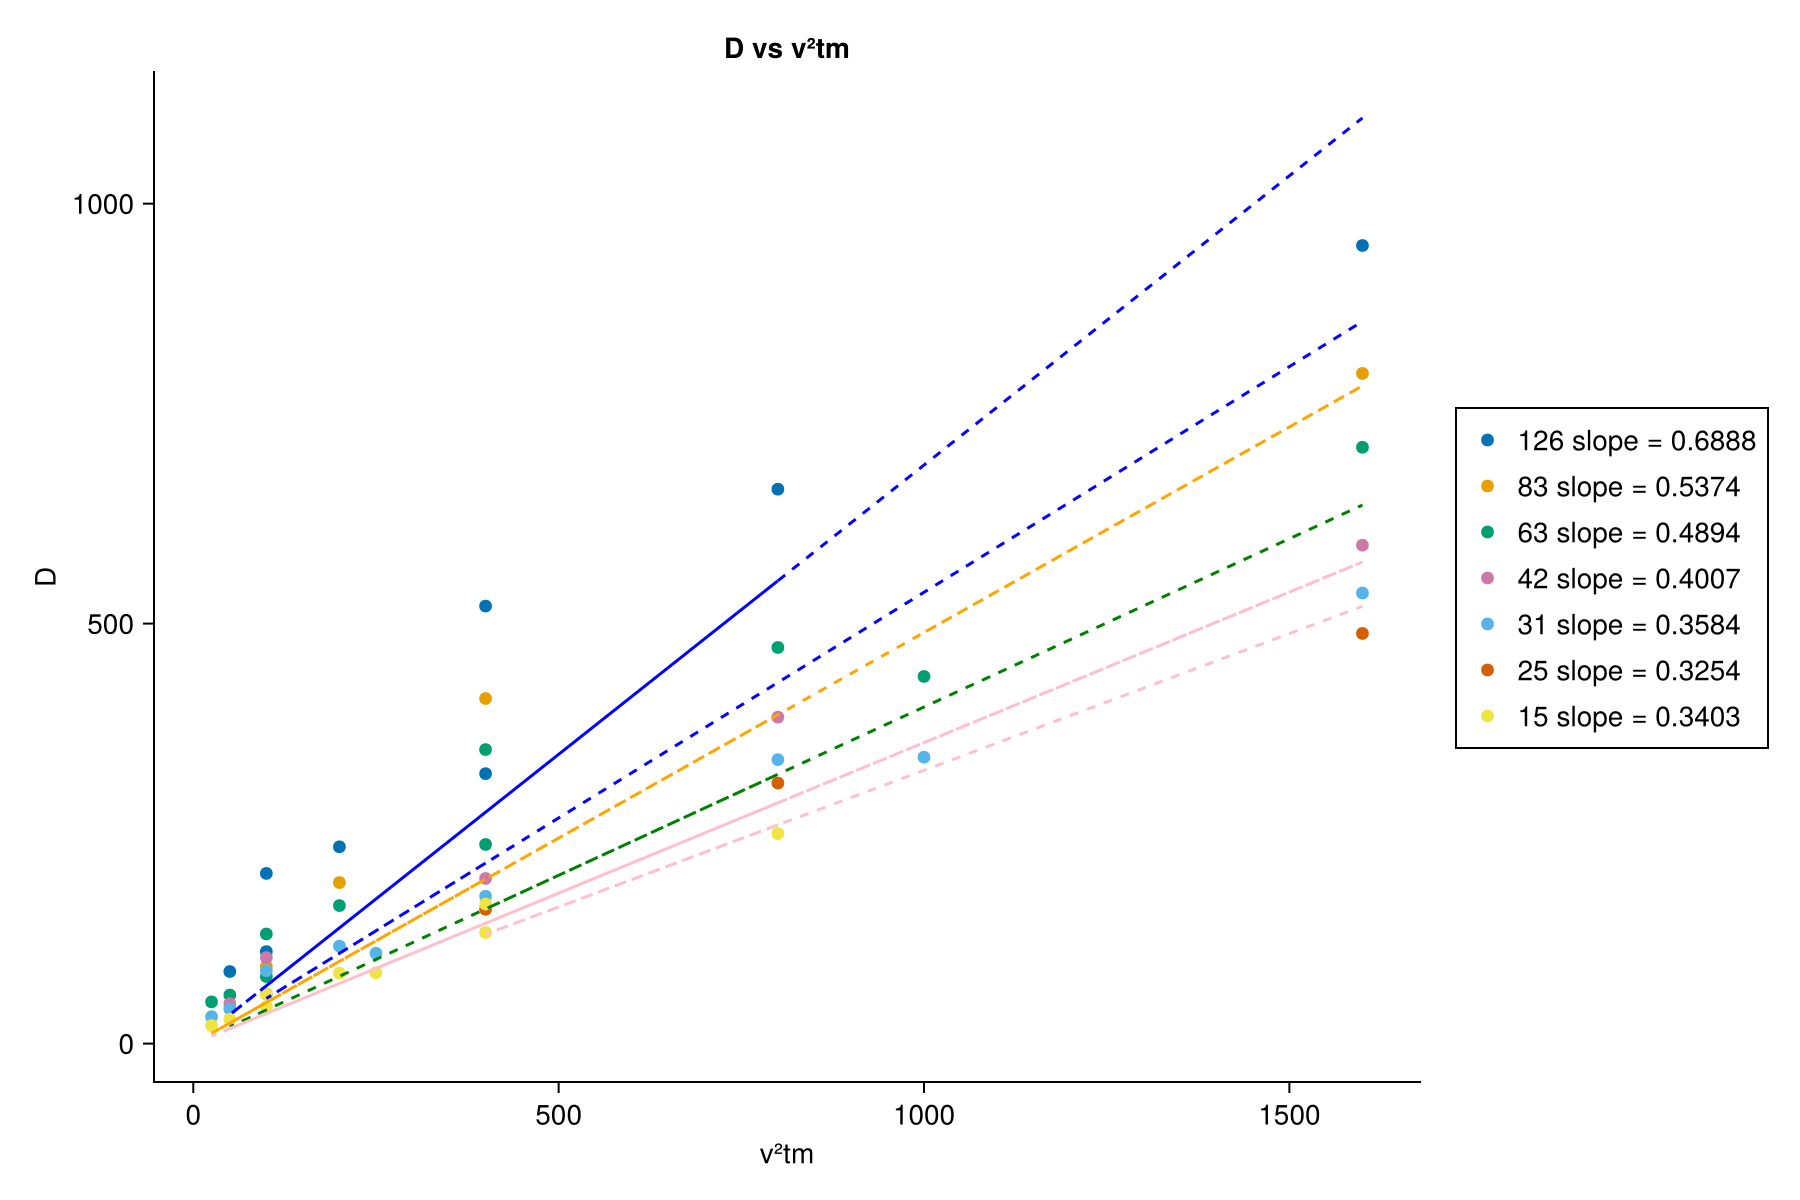

In [39]:
using CairoMakie

selected_252 = [
    (1.0, 20.0, 0.25),
    (2.0, 10.0, 0.25),
    (2.0, 20.0, 0.5),
    (4.0, 10.0, 0.5),
    (4.0, 5.0, 0.25),
    (4.0, 20.0, 1.0),
    (4.0, 100.0, 5.0)
]
selected_126 = [
    (1.0, 10.0, 0.25),
    (1.0, 20.0, 0.5),
    (2.0, 10.0, 0.5),
    (2.0, 5.0, 0.25),
    (2.0, 20.0, 1.0),
    # (2.0, 100.0, 5.0),
    (4.0, 10.0, 1.0),
    (4.0, 5.0, 0.5),
    (4.0, 20.0, 2.0),
    # (4.0, 100.0, 10.0),
    # (10.0, 20.0, 5.0)
]

selected_83 = [
    (1.0, 20.0, 0.75),
    (2.0, 10.0, 0.75),
    (4.0, 5.0, 0.75),
    (4.0, 20.0, 3.0)
]

selected_63 = [
    (1.0, 10.0, 0.5),
    (1.0, 5.0, 0.25),
    (1.0, 20.0, 1.0),
    # (1.0, 100.0, 5.0),
    (2.0, 10.0, 1.0),
    (2.0, 5.0, 0.5),
    (2.0, 20.0, 2.0),
    # (2.0, 100.0, 10.0),
    (4.0, 10.0, 2.0),
    (4.0, 5.0, 1.0),
    (4.0, 20.0, 4.0),
    (10.0, 10.0, 5.0),
    # (10.0, 20.0, 10.0)
]

selected_42 = [
    (1.0, 10.0, 0.75),
    (2.0, 5.0, 0.75),
    (2.0, 20.0, 3.0),
    (4.0, 10.0, 3.0),
    (4.0, 20.0, 6.0)
]

selected_31 = [
    (1.0, 10.0, 1.0),
    (1.0, 5.0, 0.5),
    # (1.0, 100.0, 10.0),
    (2.0, 10.0, 2.0),
    (2.0, 5.0, 1.0),
    (2.0, 20.0, 4.0),
    (4.0, 10.0, 4.0),
    (4.0, 5.0, 2.0),
    (4.0, 20.0, 8.0),
    (10.0, 10.0, 10.0),
    (10.0, 5.0, 5.0)
]

selected_25 = [
    (2.0, 20.0, 5.0),
    (4.0, 10.0, 5.0),
    (4.0, 20.0, 10.0)
]

selected_21 = [
    (1.0, 5.0, 0.75),
    (1.0, 20.0, 3.0),
    (2.0, 10.0, 3.0),
    (2.0, 20.0, 6.0),
    (4.0, 10.0, 6.0),
    (4.0, 5.0, 3.0)
]

selected_15 = [
    (1.0, 10.0, 2.0),
    (1.0, 5.0, 1.0),
    (1.0, 20.0, 4.0),
    (2.0, 10.0, 4.0),
    (2.0, 5.0, 2.0),
    (2.0, 20.0, 8.0),
    (4.0, 10.0, 8.0),
    (4.0, 5.0, 4.0),
    (10.0, 5.0, 10.0)
]


vtm_252 = Float64[]
diff_252 = Float64[]
vtm_126 = Float64[]
diff_126 = Float64[]
vtm_83 = Float64[]
diff_83 = Float64[]
vtm_63 = Float64[]
diff_63 = Float64[]
vtm_42 = Float64[]
diff_42 = Float64[]
vtm_31 = Float64[]
diff_31 = Float64[]
vtm_25 = Float64[]
diff_25 = Float64[]
vtm_21 = Float64[]
diff_21 = Float64[]
vtm_15 = Float64[]
diff_15 = Float64[]

# for (tm, v, n) in selected_252

#     mask = (metrics_all.tm .== tm) .&
#            (metrics_all.v  .== v)  .&
#            (metrics_all.l  .== n)

#     row = metrics_all[mask, :]

#     if nrow(row) == 0
#         @warn "No match for ($tm, $v, $n)"
#         continue
#     end

#     D = row.variance[1]   # replace variance by the correct D column if needed

#     push!(vtm_252, v^2 * tm)
#     push!(vtm_252, D)
# end
for (tm, v, n) in selected_126

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_126, v^2 * tm)
    push!(diff_126, D)
end

for (tm, v, n) in selected_83

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_83, v^2 * tm)
    push!(diff_83, D)
end
for (tm, v, n) in selected_63

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_63, v^2 * tm)
    push!(diff_63, D)
end
for (tm, v, n) in selected_42

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_42, v^2 * tm)
    push!(diff_42, D)
end

for (tm, v, n) in selected_31

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_31, v^2 * tm)
    push!(diff_31, D)
end
for (tm, v, n) in selected_25

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_25, v^2 * tm)
    push!(diff_25, D)
end
for (tm, v, n) in selected_21

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_21, v^2 * tm)
    push!(diff_21, D)
end
for (tm, v, n) in selected_15

    mask = (metrics_all.tm .== tm) .&
           (metrics_all.v  .== v)  .&
           (metrics_all.l  .== n)

    row = metrics_all[mask, :]

    if nrow(row) == 0
        @warn "No match for ($tm, $v, $n)"
        continue
    end

    D = row.variance[1]   # replace variance by the correct D column if needed

    push!(vtm_15, v^2 * tm)
    push!(diff_15, D)
end


fig = Figure(size = (900, 600))
ax = CairoMakie.Axis(
    fig[1,1],
    title = "D vs v²tm",
    xlabel = "v²tm",
    ylabel = "D"
)

# scatter!(ax, vtm, diff)
# slope_252 = linear_fit_mx(vtm_252, diff_252)
slope_126 = linear_fit_mx(vtm_126, diff_126)
slope_83 = linear_fit_mx(vtm_83, diff_83)
slope_63 = linear_fit_mx(vtm_63, diff_63)
slope_42 = linear_fit_mx(vtm_42, diff_42)
slope_31 = linear_fit_mx(vtm_31, diff_31)
slope_25 = linear_fit_mx(vtm_25, diff_25)
slope_21 = linear_fit_mx(vtm_21, vtm_21)
slope_15 = linear_fit_mx(vtm_15, diff_15)

# scatter!(ax, vtm_252, diff_252, label = "252 slope = $(round(slope_252, digits=4))")
scatter!(ax, vtm_126, diff_126, label = "126 slope = $(round(slope_126, digits=4))")
scatter!(ax, vtm_83, diff_83, label = "83 slope = $(round(slope_83, digits=4))")
scatter!(ax, vtm_63, diff_63, label = "63 slope = $(round(slope_63, digits=4))")
scatter!(ax, vtm_42, diff_42, label = "42 slope = $(round(slope_42, digits=4))")
scatter!(ax, vtm_31, diff_31, label = "31 slope = $(round(slope_31, digits=4))")
scatter!(ax, vtm_25, diff_25, label = "25 slope = $(round(slope_25, digits=4))")
# scatter!(ax, vtm_21, vtm_21, label = "21 slope = $(round(slope_21, digits=4))")
scatter!(ax, vtm_15, diff_15, label = "15 slope = $(round(slope_15, digits=4))")

# lines!(ax, vtm_252, slope_252 .* vtm_252 ,linestyle = :dash, color = :blue)
lines!(ax, vtm_126, slope_126 .* vtm_126 ,linestyle = :dash, color = :blue)
lines!(ax, vtm_83, slope_83 .* vtm_83 ,linestyle = :dash, color = :blue)
lines!(ax, vtm_63, slope_63 .* vtm_63 ,linestyle = :dash, color = :orange)
lines!(ax, vtm_42, slope_42 .* vtm_42 ,linestyle = :dash, color = :green)
lines!(ax, vtm_31, slope_31 .* vtm_31 ,linestyle = :dash, color = :pink)
lines!(ax, vtm_25, slope_25 .* vtm_25 ,linestyle = :dash, color = :pink)
# lines!(ax, vtm_21, slope_21 .* vtm_21 ,linestyle = :dash, color = :pink)
# lines!(ax, vtm_15, slope_15 .* vtm_15 ,linestyle = :dash, color = :lightblue)

ax.topspinevisible = false
ax.rightspinevisible = false
ax.ygridvisible = false
ax.xgridvisible = false

fig[1,2] = Legend(fig, ax)
fig

In [38]:
save("Plots/Fixed_source_model/Next/d_vtm_l_grid_2.pdf", fig)

CairoMakie.Screen{PDF}


In [25]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

linear_fit (generic function with 1 method)

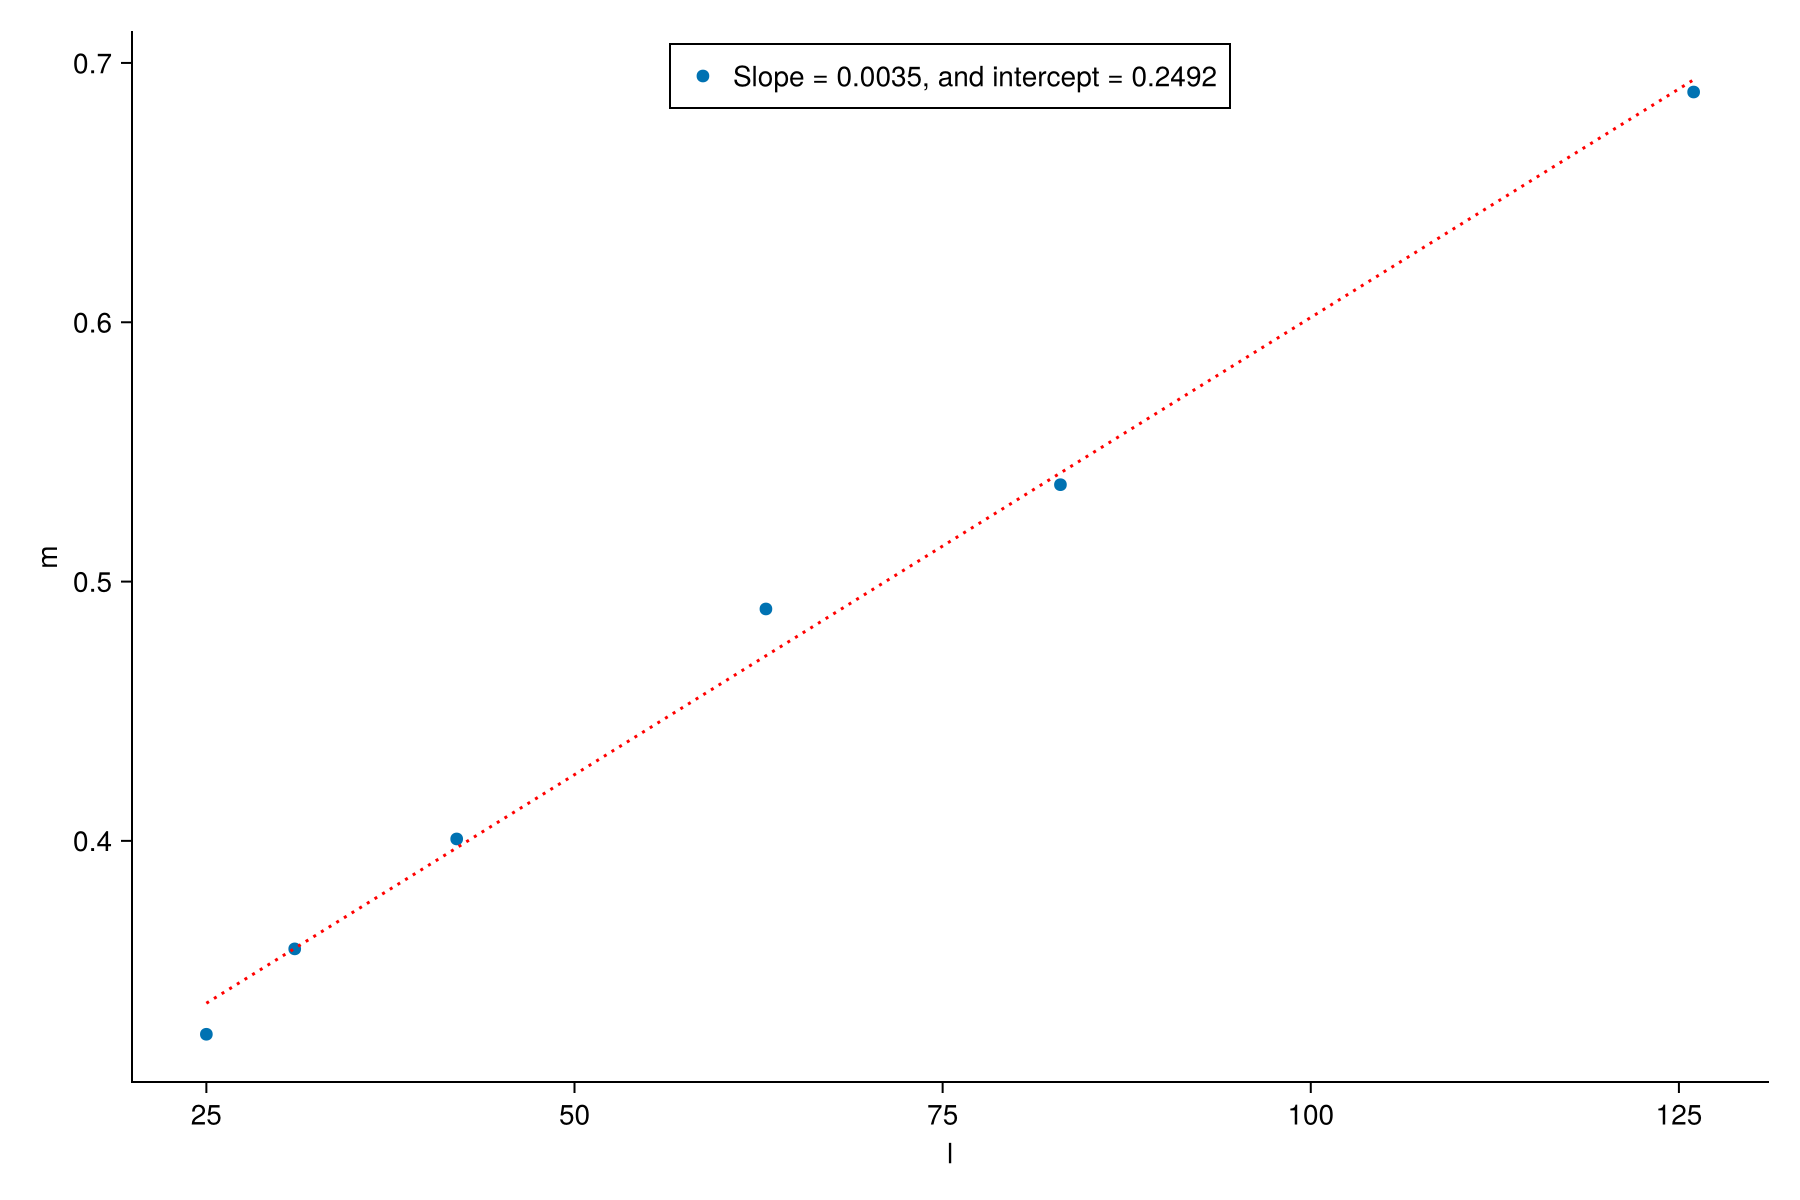

In [49]:
fig = Figure(size=(900, 600))
ax = CairoMakie.Axis(fig[1,1], xlabel = "l", ylabel = "m")
m = [slope_25, slope_31, slope_42, slope_63, slope_83, slope_126]
l =  [25, 31, 42, 63, 83, 126]
slope_lm, intercept = linear_fit(l, m)
scatter!(ax, l, m, label ="Slope = $(round(slope_lm, digits = 4)), and intercept = $(round(intercept, digits = 4))")
lines!(ax, l, intercept .+ l .* slope_lm, linestyle = :dot, color = :red)
axislegend(ax, position = :ct)
ax.topspinevisible = false
ax.rightspinevisible = false
ax.ygridvisible = false
ax.xgridvisible = false
fig

In [51]:
save("Plots/Fixed_source_model/Next/l_m_slope_2.pdf", fig)

CairoMakie.Screen{PDF}


In [130]:
sort(metrics_all.k)

252-element Vector{Float64}:
 0.4114055583209632
 0.438094756971233
 0.4531989397352447
 0.5575777979005639
 0.588733683086778
 0.607739152574746
 0.6247367476983707
 0.626798879289739
 0.6524463828888039
 0.6546449694796077
 ⋮
 2.172150874287995
 2.1842000259490697
 2.194525545401695
 2.206443589270072
 2.2091003649278025
 2.2702036135213683
 2.2815238210391686
 2.308767841890962
 2.3138658787955837

# Crypts

In [2]:
function wall_y(x, w, d, y0, xstart, xend)
    
    # outside wall region → flat at baseline
    if x < xstart || x > xend
        return y0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    # square-wave pattern (0 or -d), then shift up by y0
    return y0 - d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

In [115]:
dfs_add_3 = Dict{Float64, DataFrame}()

# ns = [8.0]
ns = [0.5, 3.0, 8.0]
outfiles = [1]

for (o_idx, o) in enumerate(outfiles)
    for (n_idx, n) in enumerate(ns)
        
        outfile = "c_cript_n_$(n)_3.jld2"
        

        data = Dict{Int, Any}()
        steps = 50000
        jldopen(outfile, "r") do file
            for step in 100:100:steps
                key = file[@sprintf("step_%06d", step)]
                data[step] = Dict(
                    "x" => copy(key["x"]),
                    "y" => copy(key["y"])
                )
            end
        end

        x1, x2, y1, y2 = 0, 500, 0, 500
        med1, med2 = 250, 250

        width = 62
        depth = 200
        y_start = y2/2
        x_start = 20
        x_end = x2
        dx = (x2 - x1) / med1
        dy = (y2 -y1) / med2

        xcoord(i1_) = x1 + (i1_ - 1) * dx
        ycoord(i2_) = y1 + (i2_ - 1) * dy
        Nx = med1
        Ny = med2

        mask_raw = zeros(Bool, med1, med2)
        M0 = zeros(Bool, med1, med2)
        MXL = zeros(Bool, med1, med2)
        MXR = zeros(Bool, med1, med2)
        MYT = zeros(Bool, med1, med2)

        for i in 1:Nx, j in 1:Ny
            x = xcoord(i)
            y = ycoord(j)
            mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
        end

        for i in 2:Nx-1, j in 2:Ny-1
            if mask_raw[i,j] &&
            mask_raw[i+1,j] &&
            mask_raw[i-1,j] &&
            mask_raw[i,j+1] &&
            mask_raw[i,j-1] &&
            mask_raw[i+1,j+1] &&
            mask_raw[i+1,j-1] &&
            mask_raw[i-1,j+1] &&
            mask_raw[i-1,j-1]

                M0[i,j] = true
            end
        end

        for i in 2:Nx-1, j in 2:Ny-1

            if M0[i,j] == 1

                # --- HORIZONTAL LINES ---
                # bottom edge (neighbor below is outside)
                if M0[i, j-1] == 0
                    MYT[i,j] = true
                end

                # top edge (neighbor above is outside)
                if M0[i, j+1] == 0
                    MYT[i,j] = true
                end


                # --- LEFT WALL ---
                if M0[i-1, j] == 0
                    MXL[i,j] = true
                end


                # --- RIGHT WALL ---
                if M0[i+1, j] == 0
                    MXR[i,j] = true
                end

            end
        end


        ncripts = 8
        steps_t = 100:100:steps
        sizes = length(steps_t)
        counts = zeros(ncripts, sizes)
        agents = Float64[]
        counts_in = Float64[]
        counts_out = Float64[]

        density_lumen = Float64[]
        density_crypt = Float64[]

        residence_time = Float64[]

        occupancy = Float64[]

        for i in 1:sizes
            count_in = 0
            count_out = 0
            agent = 0
            step = steps_t[i]
            g = data[step]
            x = g["x"]
            y = g["y"]
            
            for j in 1:length(x)

                if y[j] < 250 && y[j] != 0
                    count_in += 1
                    agent += 1

                elseif y[j] > 250 && y[j] != 0
                    count_out += 1
                    agent += 1

                end          

            end

            area_lumen = 250 * 500
            area_crypt = ncripts * (62/2) * 200 ## ncripts * width/2 * depth
            d_l = count_out / area_lumen
            d_c = count_in / area_crypt
            percentatge_in = (count_in / agent) * 100

            push!(counts_in, count_in)
            push!(counts_out, count_out)
            push!(agents, agent)
            push!(density_lumen, d_l)
            push!(density_crypt, d_c)
            push!(occupancy, percentatge_in)
        end
        
        right_wall = findall(MXR[:, 100] .== 1) .* 2
        left_wall  = findall(MXL[:, 100] .== 1) .* 2

        n_bins = 8
        y_top = y_start
        y_bottom = y_start - depth

        n_steps = length(steps_t)

        counts = zeros(n_bins, n_steps)

        # Precompute x-interval bounds for each bin
        x_left  = right_wall[1:n_bins]
        x_right = left_wall[2:n_bins+1]
        
        for (i, step) in enumerate(steps_t)
            g = data[step]
            x = g["x"]
            y = g["y"]

            local_counts = zeros(Int, n_bins)

            for j in eachindex(x)
                if y[j] >= y_top
                    continue
                end

                xj = x[j]

                # find bin (much cleaner than long elseif chain)
                for b in 1:n_bins
                    if x_right[b] > xj > x_left[b]
                        local_counts[b] += 1
                        break
                    end
                end
            end

            counts[:, i] .= local_counts
        end

        df = DataFrame(
            time_vec = sizes,
            num_agents = agents,
            occupancies = occupancy,
            d_lumen = density_lumen,
            d_crypt = density_crypt,
            num_inside = counts_in,
            num_outside = counts_out, 
            crypt_1 = counts[1, :],
            crypt_2 = counts[2, :],
            crypt_3 = counts[3, :],
            crypt_4 = counts[4, :],
            crypt_5 = counts[5, :],
            crypt_6 = counts[6, :],
            crypt_7 = counts[7, :],
            crypt_8 = counts[8, :]
        )

        
        dfs_add_3[n] = df
    end
end





In [116]:
@save "dfs_add_1.jld2" dfs_add_1
@save "dfs_add_2.jld2" dfs_add_2
@save "dfs_add_3.jld2" dfs_add_3

In [4]:
@save "dfs_o2_3.jld2" dfs_o2_3


In [70]:
@save "dfs_o2_2.jld2" dfs_o2_2

In [40]:
@save "dfs_o2_1.jld2" dfs_o2_1

In [42]:
@load "dfs_o2_1.jld2" dfs_o2_1
@load "dfs_o2_2.jld2" dfs_o2_2
@load "dfs_o2_3.jld2" dfs_o2_3


1-element Vector{Symbol}:
 :dfs_o2_3

In [ ]:
using CairoMakie
steps = 100:100:50000
sizes = length(steps)

# ns = [0.5, 3.0]
ns = [0.5, 3.0, 8.0]


# for (v_idx, v) in enumerate(classes)

    fig = Figure(size = (1800, 1200))

    ax1 = CairoMakie.Axis(fig[1,1], title="Proportion", xlabel="Time (s)", ylabel="nº agents in / nº agents out")
    ax2 = CairoMakie.Axis(fig[1,2], title="Biomass", xlabel="Time (s)", ylabel="nº agents")
    ax3 = CairoMakie.Axis(fig[2,1], title="Enrichment", xlabel="Time (s)", ylabel="p crypt / p lumen")
    ax4 = CairoMakie.Axis(fig[2,2], title="Residence time", xlabel="Time (s)", ylabel="Distribution")
    ax5 = CairoMakie.Axis(fig[3,1], title="Occupancy", xlabel="Time (s)", ylabel="% bacteria inside")
    ax6 = CairoMakie.Axis(fig[3,2], title="Crypt colonization over time", xlabel="Time (s)", ylabel="nº agents in")

    for l in ns
        # df = dfs_pbc_add[(v, l)]
        df = dfs_o2_1[(l)]
        t = (1:sizes) .* 10

        # Biomass
        lines!(ax2, t, df.num_agents, label = "Total (n=$l)")
        lines!(ax2, t, df.num_inside, label = "In crypt (n=$l)")
        lines!(ax2, t, df.num_outside, label = "In lumen (n=$l)")

        # Enrichment
        lines!(ax3, t, df.d_crypt ./ df.d_lumen, label = "n=$l")

        # Proportion
        lines!(ax1, t, df.num_inside ./ df.num_outside, label = "n=$l")

        # Occupancy
        lines!(ax5, t, df.occupancies, label = "n=$l")

        # Crypts
        lines!(ax6, 1:sizes, df.crypt_1, label="C1 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_2, label="C2 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_3, label="C3 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_4, label="C4 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_5, label="C5 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_6, label="C6 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_7, label="C7 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_8, label="C8 n=$l", linewidth=1)
    end

    fig[1, 3] = Legend(fig, ax2)
    fig[3, 3] = Legend(fig, ax6)

    save("Plots/Cripts/Next/analysis_02_all_ns.png", fig)
# end

In [17]:
@save "dfs_pbc_add.jld2" dfs_pbc_add

In [111]:
@load "dfs_pbc_add.jld2" dfs_pbc_add

1-element Vector{Symbol}:
 :dfs_pbc_add

In [71]:
steps = 100:100:50000
sizes = length(steps)

ns = [0.5, 3.0, 8.0]
class = ["pbc"]

# for (v_idx, v) in enumerate(class)
        
    for (l_idx, l) in enumerate(ns)

        df = dfs_o2_2[(l)]
        # df = dfs_pbc_add[(v, l)]

        fig = Figure(size=(1800, 1200))
        ax1 = CairoMakie.Axis(fig[1,1], title = "Proportion", xlabel = "Time (s)", ylabel = "nº agents in / nº agents out")
        ax2 = CairoMakie.Axis(fig[1,2], title = "Biomass", xlabel = "Time (s)", ylabel = "nº agents")
        ax3 = CairoMakie.Axis(fig[2,1], title = "Enrichment", xlabel = "Time (s)", ylabel = "p crypt / p lumen")
        ax4 = CairoMakie.Axis(fig[2,2], title = "Residence time", xlabel = "Time (s)", ylabel = "Distribution")
        ax5 = CairoMakie.Axis(fig[3,1], title = "Occupancy", xlabel = "Time (s)", ylabel = "% bacteria inside")
        ax6 = CairoMakie.Axis(fig[3,2], title = "Cript colonization over time", xlabel = "Time (s)", ylabel = "nº agents in")

        lines!(ax2, (1:sizes)*10, df.num_agents, label = "Total")
        lines!(ax2, (1:sizes)*10, df.num_inside, label = "In crypt")
        lines!(ax2, (1:sizes)*10, df.num_outside, label = "In lumen")

        lines!(ax3, (1:sizes)*10, df.d_crypt ./ df.d_lumen)

        proportion = df.num_inside ./ df.num_outside
        lines!(ax1, (1:sizes)*10, proportion)

        # hist!(ax4, residence_time, bins = 50)

        lines!(ax5, (1:sizes)*10, df.occupancies)

        lines!(ax6, (1:sizes), df.crypt_1, label = "Cript 1", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_2, label = "Cript 2", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_3, label = "Cript 3", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_4, label = "Cript 4", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_5, label = "Cript 5", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_6, label = "Cript 6", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_7, label = "Cript 7", linewidth         = 1)
        lines!(ax6, (1:sizes), df.crypt_8, label = "Cript 8", linewidth         = 1)

        fig[1, 3] = Legend(fig, ax2)
        fig[3, 3] = Legend(fig, ax6)
        fig
        save("Plots/Cripts/Next/analysis_o2_0.5_2.png", fig)
    end
# end


In [ ]:
using CairoMakie
steps = 100:100:50000
sizes = length(steps)

# ns = [0.5, 3.0]
ns = [0.5, 3.0, 8.0]


# for (v_idx, v) in enumerate(classes)

    fig = Figure(size = (1800, 1200))

    ax1 = CairoMakie.Axis(fig[1,1], title="Proportion", xlabel="Time (s)", ylabel="nº agents in / nº agents out")
    ax2 = CairoMakie.Axis(fig[1,2], title="Biomass", xlabel="Time (s)", ylabel="nº agents")
    ax3 = CairoMakie.Axis(fig[2,1], title="Enrichment", xlabel="Time (s)", ylabel="p crypt / p lumen")
    ax4 = CairoMakie.Axis(fig[2,2], title="Residence time", xlabel="Time (s)", ylabel="Distribution")
    ax5 = CairoMakie.Axis(fig[3,1], title="Occupancy", xlabel="Time (s)", ylabel="% bacteria inside")
    ax6 = CairoMakie.Axis(fig[3,2], title="Crypt colonization over time", xlabel="Time (s)", ylabel="nº agents in")

    for l in ns
        # df = dfs_pbc_add[(v, l)]
        df = dfs_o2_1[(l)]
        t = (1:sizes) .* 10

        # Biomass
        lines!(ax2, t, df.num_agents, label = "Total (n=$l)")
        lines!(ax2, t, df.num_inside, label = "In crypt (n=$l)")
        lines!(ax2, t, df.num_outside, label = "In lumen (n=$l)")

        # Enrichment
        lines!(ax3, t, df.d_crypt ./ df.d_lumen, label = "n=$l")

        # Proportion
        lines!(ax1, t, df.num_inside ./ df.num_outside, label = "n=$l")

        # Occupancy
        lines!(ax5, t, df.occupancies, label = "n=$l")

        # Crypts
        lines!(ax6, 1:sizes, df.crypt_1, label="C1 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_2, label="C2 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_3, label="C3 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_4, label="C4 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_5, label="C5 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_6, label="C6 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_7, label="C7 n=$l", linewidth=1)
        lines!(ax6, 1:sizes, df.crypt_8, label="C8 n=$l", linewidth=1)
    end

    fig[1, 3] = Legend(fig, ax2)
    fig[3, 3] = Legend(fig, ax6)

    save("Plots/Cripts/Next/analysis_02_all_ns.png", fig)
# end

In [ ]:
using CairoMakie

steps = 100:100:25000
# steps = 100:100:50000
sizes = length(steps)

ns = [3.0, 8.0]
# ns = [0.5, 3.0, 8.0]
classes = ["pbc"]

# --- base colors for the 3 datasets ---
base_colors = [:dodgerblue, :darkorange, :seagreen]

# simple function to create a gradient (lighter variants)
gradient = [1, 0.7, 0.2]

# for v in classes

    fig = Figure(size = (1800, 1200))

    ax1 = CairoMakie.Axis(fig[1,1], title="Proportion",
        xlabel="Time (s)", ylabel="nº agents in / nº agents out")

    ax2 = CairoMakie.Axis(fig[1,2], title="Biomass",
        xlabel="Time (s)", ylabel="nº agents")

    ax3 = CairoMakie.Axis(fig[2,1], title="Enrichment",
        xlabel="Time (s)", ylabel="p crypt / p lumen")

    ax6 = CairoMakie.Axis(fig[2,2], title="Crypt colonization over time",
        xlabel="Time (s)", ylabel="nº agents in")

    for (i, l) in enumerate(ns)

        # df = dfs_pbc_add[(v, l)]
        df = dfs_o2[(l)]
        
        t = (1:sizes) .* 10
        c = base_colors[i]

        # --- ax1: proportion (3 fixed colors) ---
        lines!(ax1, t, df.num_inside ./ df.num_outside,
            color = c, label = "n=$l")

        # --- ax3: enrichment (3 fixed colors) ---
        lines!(ax3, t, df.d_crypt ./ df.d_lumen,
            color = c, label = "n=$l")

        # --- ax2: biomass (gradient per dataset) ---
        # grad = color_gradient(c, i)

        lines!(ax2, t, df.num_agents,
            color = (c, gradient[1]), label = "Total n=$l")

        lines!(ax2, t, df.num_inside,
            color = (c, gradient[2]), label = "Inside n=$l")

        lines!(ax2, t, df.num_outside,
            color = (c, gradient[3]), label = "Outside n=$l")

        # --- ax6: crypts (same dataset color) ---
        for k in 1:8
            lines!(ax6, 1:sizes, getproperty(df, Symbol("crypt_$k")),
                color = c, linewidth = 1,
                label = k == 1 ? "n=$l" : nothing)
        end
    end

    CairoMakie.axislegend(ax2, position = :rb)
    CairoMakie.axislegend(ax6, position = :rb)

    save("Plots/Cripts/Next/analysis_pbc_$(v)_all_ns.png", fig)
end

In [43]:
using CairoMakie
using Statistics

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------

function mean_std_vectors(vectors)
    M = reduce(hcat, vectors)
    μ = vec(mean(M, dims = 2))
    σ = vec(std(M, dims = 2))
    return μ, σ
end

function plot_mean_band!(ax, x, vectors; label="")
    μ, σ = mean_std_vectors(vectors)

    band!(ax, x, μ .- σ, μ .+ σ, alpha = 0.2)
    lines!(ax, x, μ, linewidth = 3, label = label)

    return nothing
end

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------

steps = 100:100:50000
sizes = length(steps)

ns = [0.5, 3.0, 8.0]

runs = [dfs_o2_1, dfs_o2_2, dfs_o2_3]

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------

fig = Figure(size = (1800, 1200))

ax1 = Axis(
    fig[1,1],
    title = "Proportion",
    xlabel = "Time (s)",
    ylabel = "nº agents in / nº agents out"
)

ax2 = Axis(
    fig[1,2],
    title = "Biomass",
    xlabel = "Time (s)",
    ylabel = "nº agents"
)

ax3 = Axis(
    fig[2,1],
    title = "Enrichment",
    xlabel = "Time (s)",
    ylabel = "p crypt / p lumen"
)

ax4 = Axis(
    fig[2,2],
    title = "Residence time",
    xlabel = "Time (s)",
    ylabel = "Distribution"
)

ax5 = Axis(
    fig[3,1],
    title = "Occupancy",
    xlabel = "Time (s)",
    ylabel = "% bacteria inside"
)

ax6 = Axis(
    fig[3,2],
    title = "Crypt colonization over time",
    xlabel = "Time (s)",
    ylabel = "nº agents in"
)

# ------------------------------------------------------------------
# Main loop over n values
# ------------------------------------------------------------------

for n in ns

    dfs = [run[n] for run in runs]

    t = (1:sizes) .* 10

    # --------------------------------------------------------------
    # Biomass
    # --------------------------------------------------------------

    plot_mean_band!(
        ax2,
        t,
        [df.num_agents for df in dfs],
        label = "Total (n=$n)"
    )

    plot_mean_band!(
        ax2,
        t,
        [df.num_inside for df in dfs],
        label = "Inside (n=$n)"
    )

    plot_mean_band!(
        ax2,
        t,
        [df.num_outside for df in dfs],
        label = "Outside (n=$n)"
    )

    # --------------------------------------------------------------
    # Enrichment
    # --------------------------------------------------------------

    plot_mean_band!(
        ax3,
        t,
        [df.d_crypt ./ df.d_lumen for df in dfs],
        label = "n=$n"
    )

    # --------------------------------------------------------------
    # Proportion
    # --------------------------------------------------------------

    plot_mean_band!(
        ax1,
        t,
        [df.num_inside ./ df.num_outside for df in dfs],
        label = "n=$n"
    )

    # --------------------------------------------------------------
    # Occupancy
    # --------------------------------------------------------------

    plot_mean_band!(
        ax5,
        t,
        [df.occupancies for df in dfs],
        label = "n=$n"
    )

    # --------------------------------------------------------------
    # Crypts
    # --------------------------------------------------------------

    crypt_cols = [
        :crypt_1,
        :crypt_2,
        :crypt_3,
        :crypt_4,
        :crypt_5,
        :crypt_6,
        :crypt_7,
        :crypt_8
    ]

    for (i, crypt) in enumerate(crypt_cols)

        plot_mean_band!(
            ax6,
            1:sizes,
            [df[!, crypt] for df in dfs],
            label = "C$i n=$n"
        )
    end
end

# ------------------------------------------------------------------
# Legends
# ------------------------------------------------------------------

fig[1,3] = Legend(fig, ax2)
fig[3,3] = Legend(fig, ax6)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

save("Plots/Cripts/Next/analysis_02_all_ns_mean_std.png", fig)

## Crypt dispersion

In [ ]:
using CairoMakie
using Statistics

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------

function mean_std_vectors(vectors)
    M = reduce(hcat, vectors)
    μ = vec(mean(M, dims = 2))
    σ = vec(std(M, dims = 2))
    return μ, σ
end

function plot_mean_band!(ax, x, vectors; label="")
    μ, σ = mean_std_vectors(vectors)

    band!(ax, x, μ .- σ, μ .+ σ, alpha = 0.2)
    lines!(ax, x, μ, linewidth = 3, label = label)

    return nothing
end

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------

steps = 100:100:50000
sizes = length(steps)

ns = [0.5, 3.0, 8.0]

runs = [dfs_o2_1, dfs_o2_2, dfs_o2_3]

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------

fig = Figure(size = (1800, 1200))

ax1 = Axis(
    fig[1,1],
    title = "Proportion",
    xlabel = "Time (s)",
    ylabel = "nº agents in / nº agents out"
)

ax2 = Axis(
    fig[1,2],
    title = "Biomass",
    xlabel = "Time (s)",
    ylabel = "nº agents"
)

ax3 = Axis(
    fig[2,1],
    title = "Enrichment",
    xlabel = "Time (s)",
    ylabel = "p crypt / p lumen"
)

ax5 = Axis(
    fig[3,1],
    title = "Occupancy",
    xlabel = "Time (s)",
    ylabel = "% bacteria inside"
)

ax6 = Axis(
    fig[2,2],
    title = "Crypt colonization over time",
    xlabel = "Time (s)",
    ylabel = "nº agents in"
)

# ------------------------------------------------------------------
# Main loop over n values
# ------------------------------------------------------------------

for n in ns

    dfs = [run[n] for run in runs]

    t = (1:sizes) .* 10

    # --------------------------------------------------------------
    # Biomass
    # --------------------------------------------------------------

    plot_mean_band!(
        ax2,
        t,
        [df.num_agents for df in dfs],
        label = "Total (n=$n)"
    )

    plot_mean_band!(
        ax2,
        t,
        [df.num_inside for df in dfs],
        label = "Inside (n=$n)"
    )

    plot_mean_band!(
        ax2,
        t,
        [df.num_outside for df in dfs],
        label = "Outside (n=$n)"
    )

    # --------------------------------------------------------------
    # Enrichment
    # --------------------------------------------------------------

    plot_mean_band!(
        ax3,
        t,
        [df.d_crypt ./ df.d_lumen for df in dfs],
        label = "n=$n"
    )

    # --------------------------------------------------------------
    # Proportion
    # --------------------------------------------------------------

    plot_mean_band!(
        ax1,
        t,
        [df.num_inside ./ df.num_outside for df in dfs],
        label = "n=$n"
    )

    # --------------------------------------------------------------
    # Occupancy
    # --------------------------------------------------------------

    plot_mean_band!(
        ax5,
        t,
        [df.occupancies for df in dfs],
        label = "n=$n"
    )

    # --------------------------------------------------------------
    # Crypts
    # --------------------------------------------------------------
    
    crypt_matrix = Matrix(df[:, [:crypt_1,:crypt_2,:crypt_3,:crypt_4,
                             :crypt_5,:crypt_6,:crypt_7,:crypt_8]])

    cv = Float64[]

    for i in 1:nrow(df)

        μ = mean(crypt_matrix[i,:])
        σ = std(crypt_matrix[i,:])

        push!(cv, μ > 0 ? σ/μ : 0)

    end

    df.crypt_cv = cv

    lines!(ax, steps_t, df.crypt_cv)

end

# ------------------------------------------------------------------
# Legends
# ------------------------------------------------------------------

fig[1,3] = Legend(fig, ax2)
fig[3,3] = Legend(fig, ax6)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

save("Plots/Cripts/Next/analysis_test.png", fig)

UndefVarError: UndefVarError: `df` not defined

In [82]:
function shannon_entropy(counts)

    total = sum(counts)

    total == 0 && return 0.0

    p = counts ./ total

    H = 0.0

    for pi in p
        if pi > 0
            H -= pi * log(pi)
        end
    end

    return H
end


shannon_entropy (generic function with 1 method)

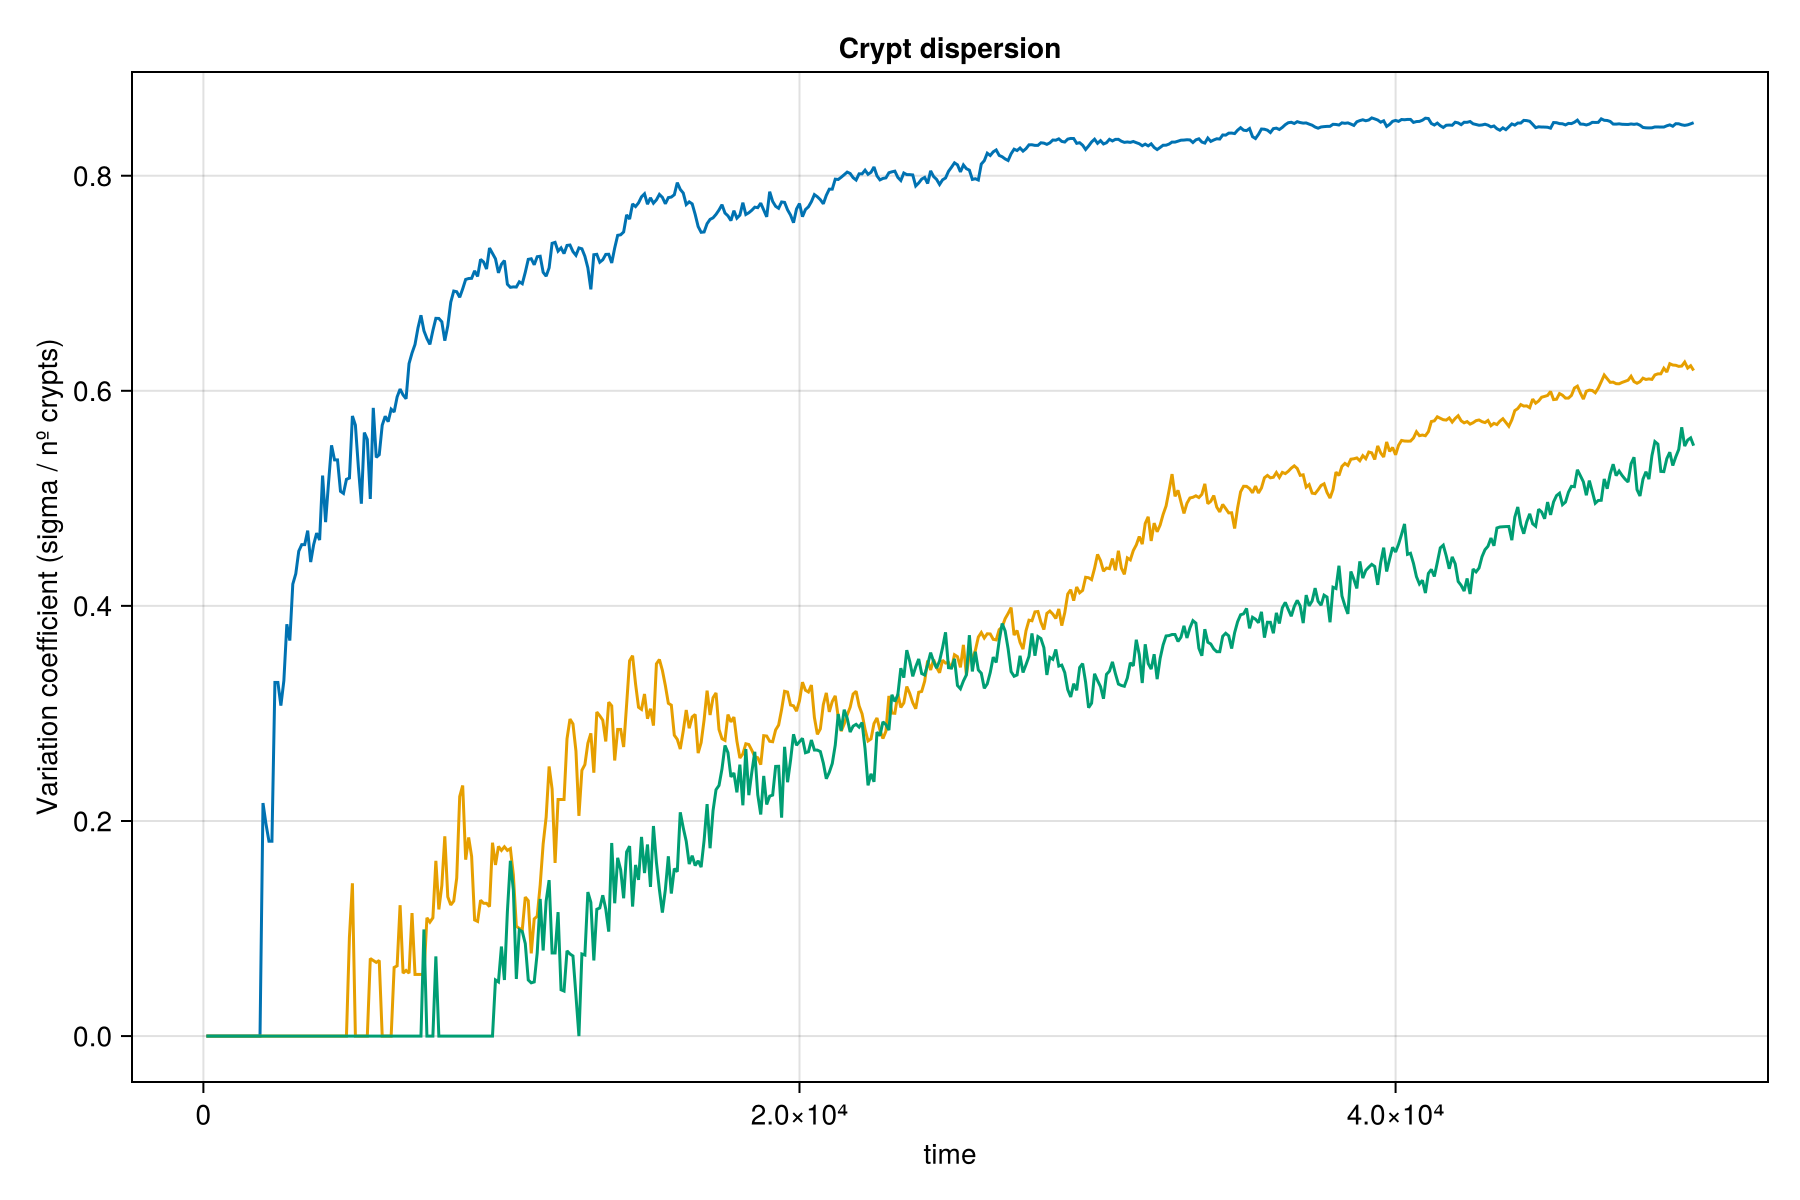

In [83]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "Crypt dispersion", xlabel = "time", ylabel = "Variation coefficient (sigma / nº crypts)")
ns = [0.5, 3.0, 8.0]
steps_t = 100:100:50000
for i in 1:3
    df = dfs_o2_1[ns[i]]
    crypt_matrix = Matrix(df[:, [:crypt_1,:crypt_2,:crypt_3,:crypt_4,
                             :crypt_5,:crypt_6,:crypt_7,:crypt_8]])

    cv = Float64[]

    # for i in 1:nrow(df)

    #     μ = mean(crypt_matrix[i,:])
    #     σ = std(crypt_matrix[i,:])

    #     push!(cv, μ > 0 ? σ/μ : 0)

    # end
    # df.crypt_std = [std(crypt_matrix[i,:]) for i in 1:nrow(df)]
    # df.crypt_cv = cv

    df.entropy = [
        shannon_entropy(crypt_matrix[i,:])
        for i in 1:nrow(df)
    ]
    df.entropy_norm = df.entropy ./ log(8)

    lines!(ax, steps_t, df.entropy_norm)
end
fig

## Last step

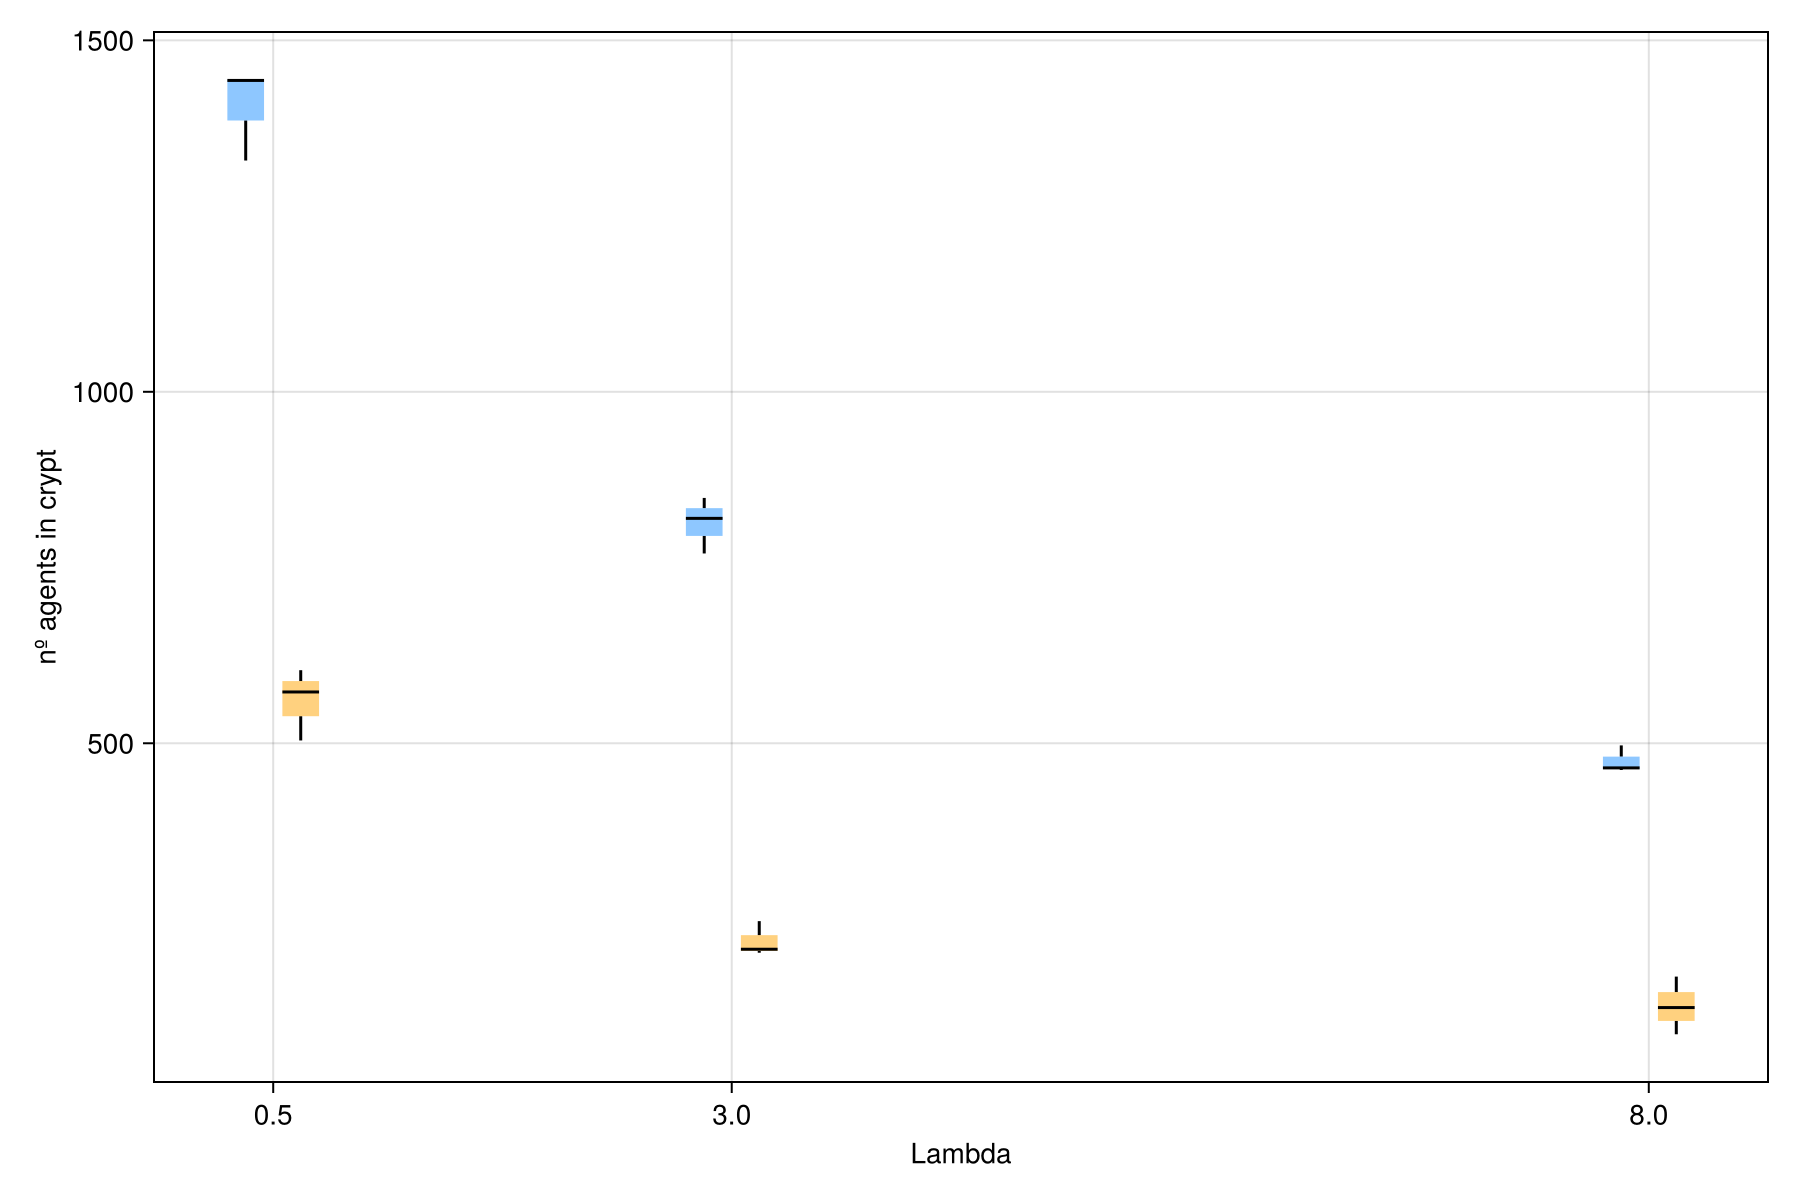

In [118]:
using CairoMakie

fig = Figure(size=(900, 600))

ax = Axis(
    fig[1,1],
    xlabel = "Lambda",
    ylabel = "nº agents in crypt"
)

ns = [0.5, 3.0, 8.0]

o2_runs  = [dfs_o2_1, dfs_o2_2, dfs_o2_3]
add_runs = [dfs_add_1, dfs_add_2, dfs_add_3]

step_idx = 500  # your selected time step

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------

o2_vals  = [Float64[] for _ in ns]
add_vals = [Float64[] for _ in ns]

for (i, n) in enumerate(ns)

    # O2 replicates
    for run in o2_runs
        df = run[n]
        push!(o2_vals[i], df[step_idx, :].num_inside)
    end

    # ADD replicates
    for run in add_runs
        df = run[n]
        push!(add_vals[i], df[step_idx, :].num_inside)
    end
end

# ------------------------------------------------------------
# Prepare boxplot positions
# ------------------------------------------------------------

x_o2  = Float64[]
x_add = Float64[]

y_o2  = Float64[]
y_add = Float64[]

offset = 0.15

for (i, n) in enumerate(ns)

    # O2 (left box)
    append!(x_o2, fill(n - offset, length(o2_vals[i])))
    append!(y_o2, o2_vals[i])

    # ADD (right box)
    append!(x_add, fill(n + offset, length(add_vals[i])))
    append!(y_add, add_vals[i])
end

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

boxplot!(ax, x_o2, y_o2, width = 0.25, color = (:dodgerblue, 0.5))
boxplot!(ax, x_add, y_add, width = 0.25, color = (:orange, 0.5))

# Optional: nicer ticks centered on λ
ax.xticks = ns

# axislegend(ax, ["O2", "ADD"])

fig
    

In [120]:
save("Plots/Cripts/Next/agents_in_o2_add.pdf", fig)

CairoMakie.Screen{PDF}


# Cluster size

In [24]:
using Images, ImageSegmentation

function periodic_labels(binary)

    # labels = label_components(binary)
    labels = label_components(binary, trues(3,3))

    nx, ny = size(binary)

    changed = true

    while changed
        changed = false

        # ---------------------------------------------
        # LEFT-RIGHT periodic merge
        # ---------------------------------------------
        for i in 1:nx

            l1 = labels[i,1]
            l2 = labels[i,end]

            if l1 > 0 && l2 > 0 && l1 != l2

                labels[labels .== l2] .= l1
                changed = true
            end
        end

        # ---------------------------------------------
        # TOP-BOTTOM periodic merge
        # ---------------------------------------------
        for j in 1:ny

            l1 = labels[1,j]
            l2 = labels[end,j]

            if l1 > 0 && l2 > 0 && l1 != l2

                labels[labels .== l2] .= l1
                changed = true
            end
        end
    end

    return labels
end

periodic_labels (generic function with 1 method)

In [148]:
function label_markers(peaks)
    labels = zeros(Int, size(peaks))

    id = 1
    for i in CartesianIndices(peaks)
        if peaks[i]
            labels[i] = id
            id += 1
        end
    end

    return labels
end

label_markers (generic function with 1 method)

In [25]:
using ImageMorphology
function compute_cluster_sizes(z; threshold=nothing)

    if threshold === nothing
        threshold = mean(z) + 0.5*std(z)
        # threshold = mean(z) + 1*std(z)
    end

    binary = z .> threshold
    # peaks = local_maxima_filtered(z)
    # markers = label_markers(peaks)
    # labels = watershed_clusters(z)
    # binary = erode(binary) #

    # periodic labeling

    labels = periodic_labels(binary)
    # labels = label_map(labels)
    cluster_ids = unique(labels)
    cluster_ids = cluster_ids[cluster_ids .> 0]

    areas = Float64[]

    for id in cluster_ids

        a = count(labels .== id)

        if a > 5
            push!(areas, a)
        end
    end

    diameters = [2 * sqrt(a / π) for a in areas]

    return diameters
end

compute_cluster_sizes (generic function with 1 method)

In [92]:
xpos = []
nobs = 3
append!(xpos, fill(1 + 0.15, nobs))

3-element Vector{Any}:
 1.15
 1.15
 1.15

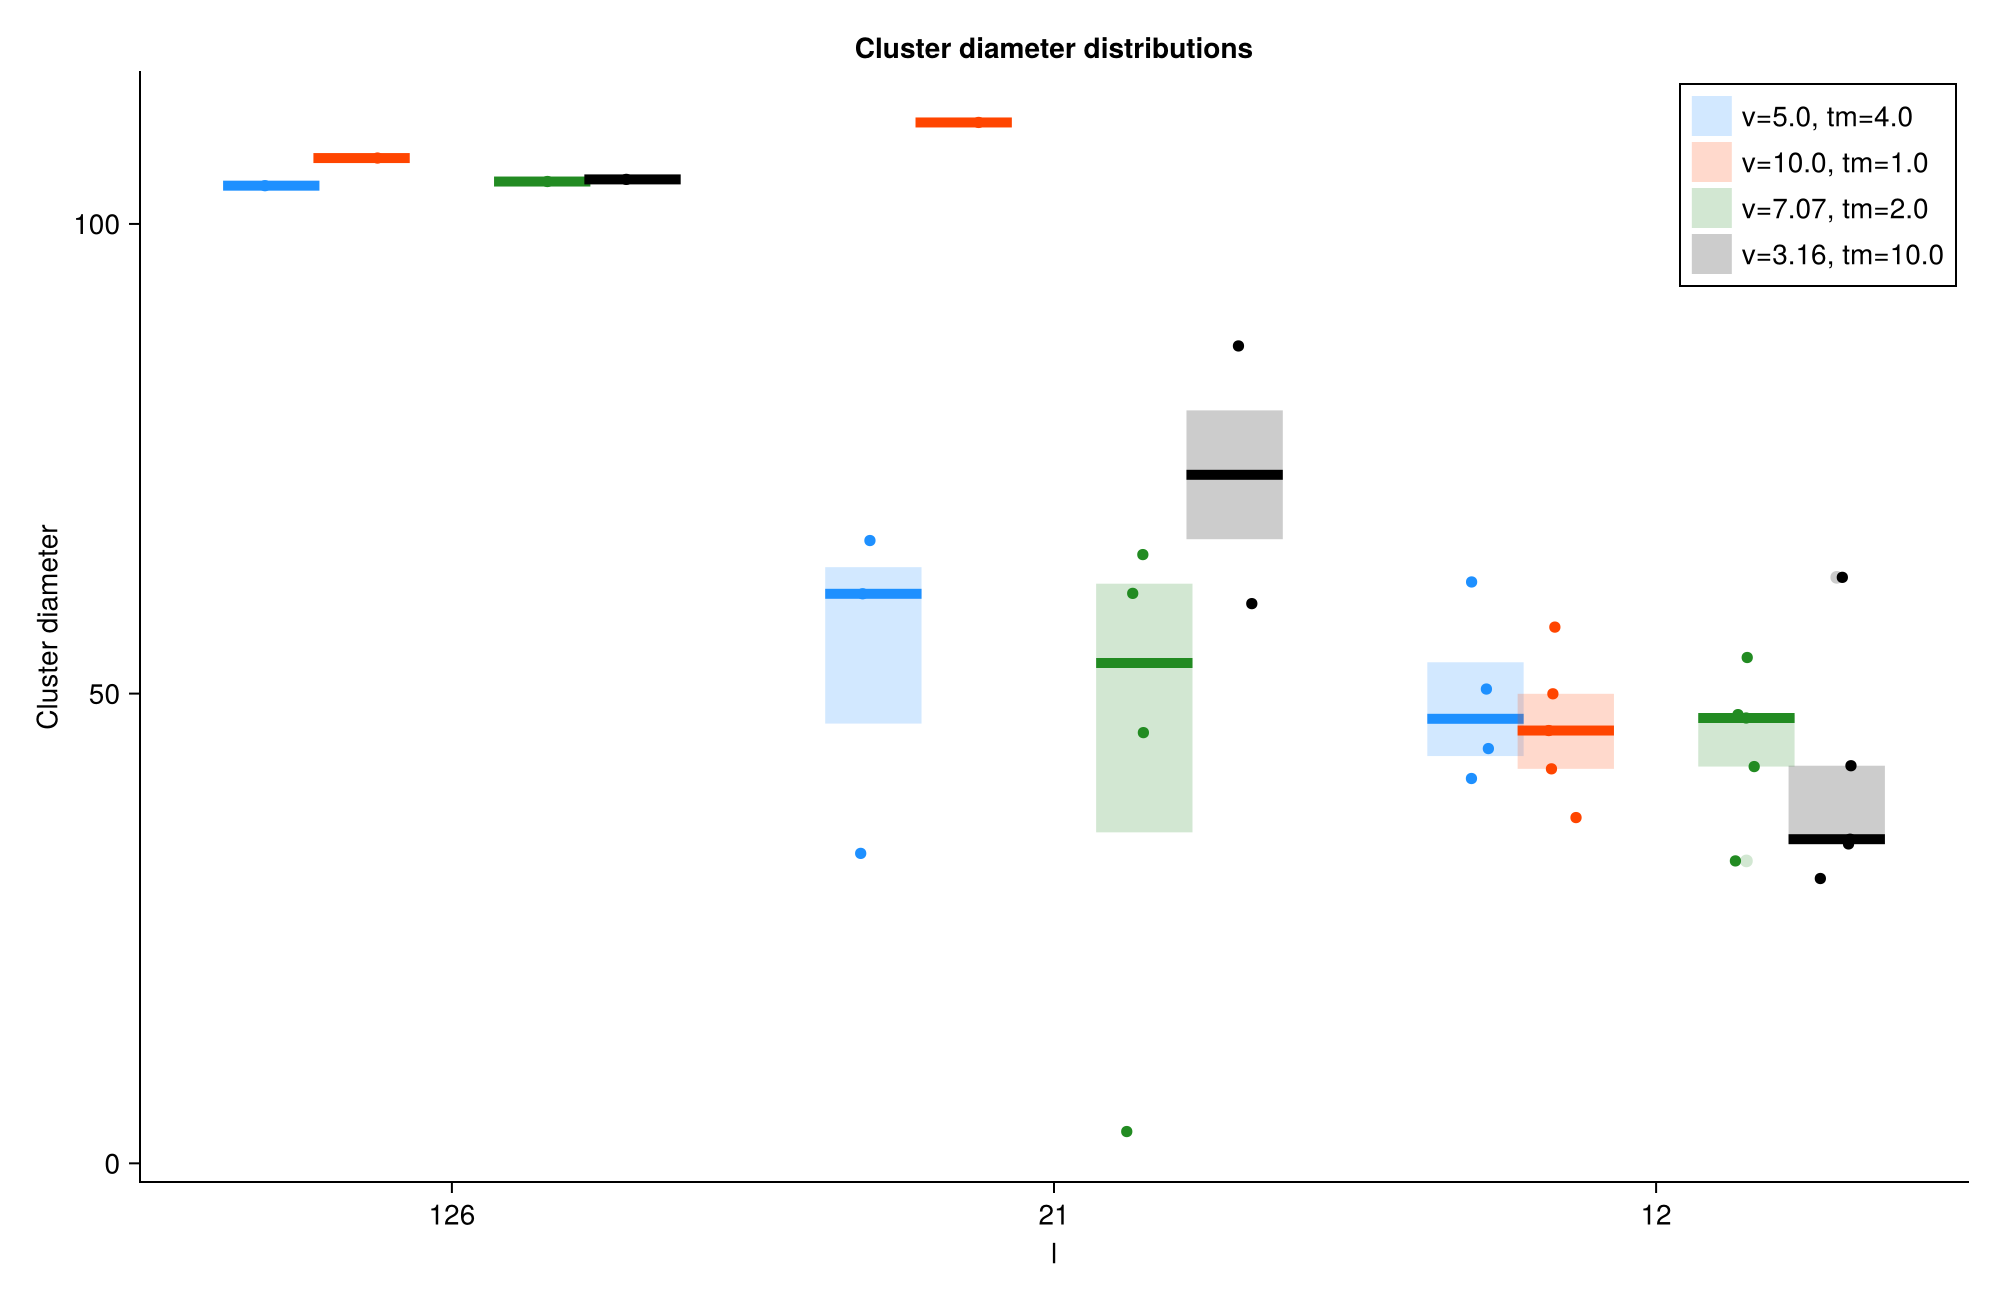

In [27]:
using CairoMakie
using JLD2
using Statistics
using Printf

# Parameters
vs  = [5.0, 10.0, 7.07, 3.16]
tms = [4.0, 1.0, 2.0, 10.0]
ls  = [126, 21, 12]
# ls  = [126, 63, 42, 31, 21, 15, 12]

timesteps = [50000]

# ------------------------------------------------------------------
# Store all individual diameters
# all_diams[i,j] corresponds to:
#   l = ls[i]
#   (v,tm) = (vs[j], tms[j])
# ------------------------------------------------------------------

all_diams = [Float64[] for _ in eachindex(ls), _ in eachindex(vs)]

for (j, v) in enumerate(vs)

    tm = tms[j]

    for (i, l) in enumerate(ls)

        filename = "cluster_v$(v)_tm_$(tm)_l$(l)).jld2"

        # println("Reading $filename")

        jldopen(filename, "r") do file

            for step in timesteps

                key = @sprintf("step_%06d", step)

                if haskey(file, key)

                    g = file[key]

                    z = reshape(g["mm_grid"], (200, 200))

                    diams = compute_cluster_sizes(z)

                    if !isempty(diams)
                        append!(all_diams[i, j], diams)
                    end
                end
            end
        end
    end
end

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig = Figure(size = (1000, 650))

ax = CairoMakie.Axis(
    fig[1, 1],
    title  = "Cluster diameter distributions",
    xlabel = "l",
    ylabel = "Cluster diameter"
)

# offsets so boxes appear side-by-side within each l category
offsets = [-0.3, -0.15, 0.15, 0.3]

colors = [:dodgerblue, :orangered, :forestgreen, :black]

labels = [
    "v=$(vs[1]), tm=$(tms[1])",
    "v=$(vs[2]), tm=$(tms[2])",
    "v=$(vs[3]), tm=$(tms[3])",
    "v=$(vs[4]), tm=$(tms[4])"
]

for j in eachindex(vs)

    xpos = Float64[]
    vals = Float64[]

    for i in eachindex(ls)

        nobs = length(all_diams[i, j])

        append!(xpos, fill(i + offsets[j], nobs))
        append!(vals, all_diams[i, j])
    end

    boxplot!(
        ax,
        xpos,
        vals,
        color = (colors[j], 0.2),
        whiskerwidth = 0.5,
        label = labels[j],
        medianlinewidth = 5,
        mediancolor = (colors[j], 8.0),
        width = 0.2,
        whiskercolor = :white
    )

    # # Overlay means
    # mean_x = Float64[]
    # mean_y = Float64[]

    # for i in eachindex(ls)

    #     if !isempty(all_diams[i, j])

    #         push!(mean_x, i + offsets[j])
    #         push!(mean_y, mean(all_diams[i, j]))

    #     end
    # end

    # scatter!(
    #     ax,
    #     mean_x,
    #     mean_y,
    #     markersize = 10,
    #     color = :black
    # )
end

for j in eachindex(vs)

    mean_x = Float64[]
    mean_y = Float64[]

    for i in eachindex(ls)

        diams = all_diams[i,j]

        if isempty(diams)
            continue
        end

        x = i .+ offsets[j] .+ 0.06 .* (rand(length(diams)) .- 0.5)

        # individual cluster diameters
        scatter!(
            ax,
            x,
            diams,
            color = colors[j],
            markersize = 8,
            alpha = 1.0
        )

        # mean diameter
        push!(mean_x, i + offsets[j])
        push!(mean_y, mean(diams))
    end
end

ax.xticks = (1:length(ls), string.(ls))

ax.topspinevisible = false
ax.rightspinevisible = false
ax.xgridvisible = false
ax.ygridvisible = false

axislegend(ax, position = :rt)

fig
# save("cluster_boxplots.png", fig)

In [28]:
save("Plots/Fixed_source_model/Next/cluster_size_box_l_1.pdf", fig)

CairoMakie.Screen{PDF}


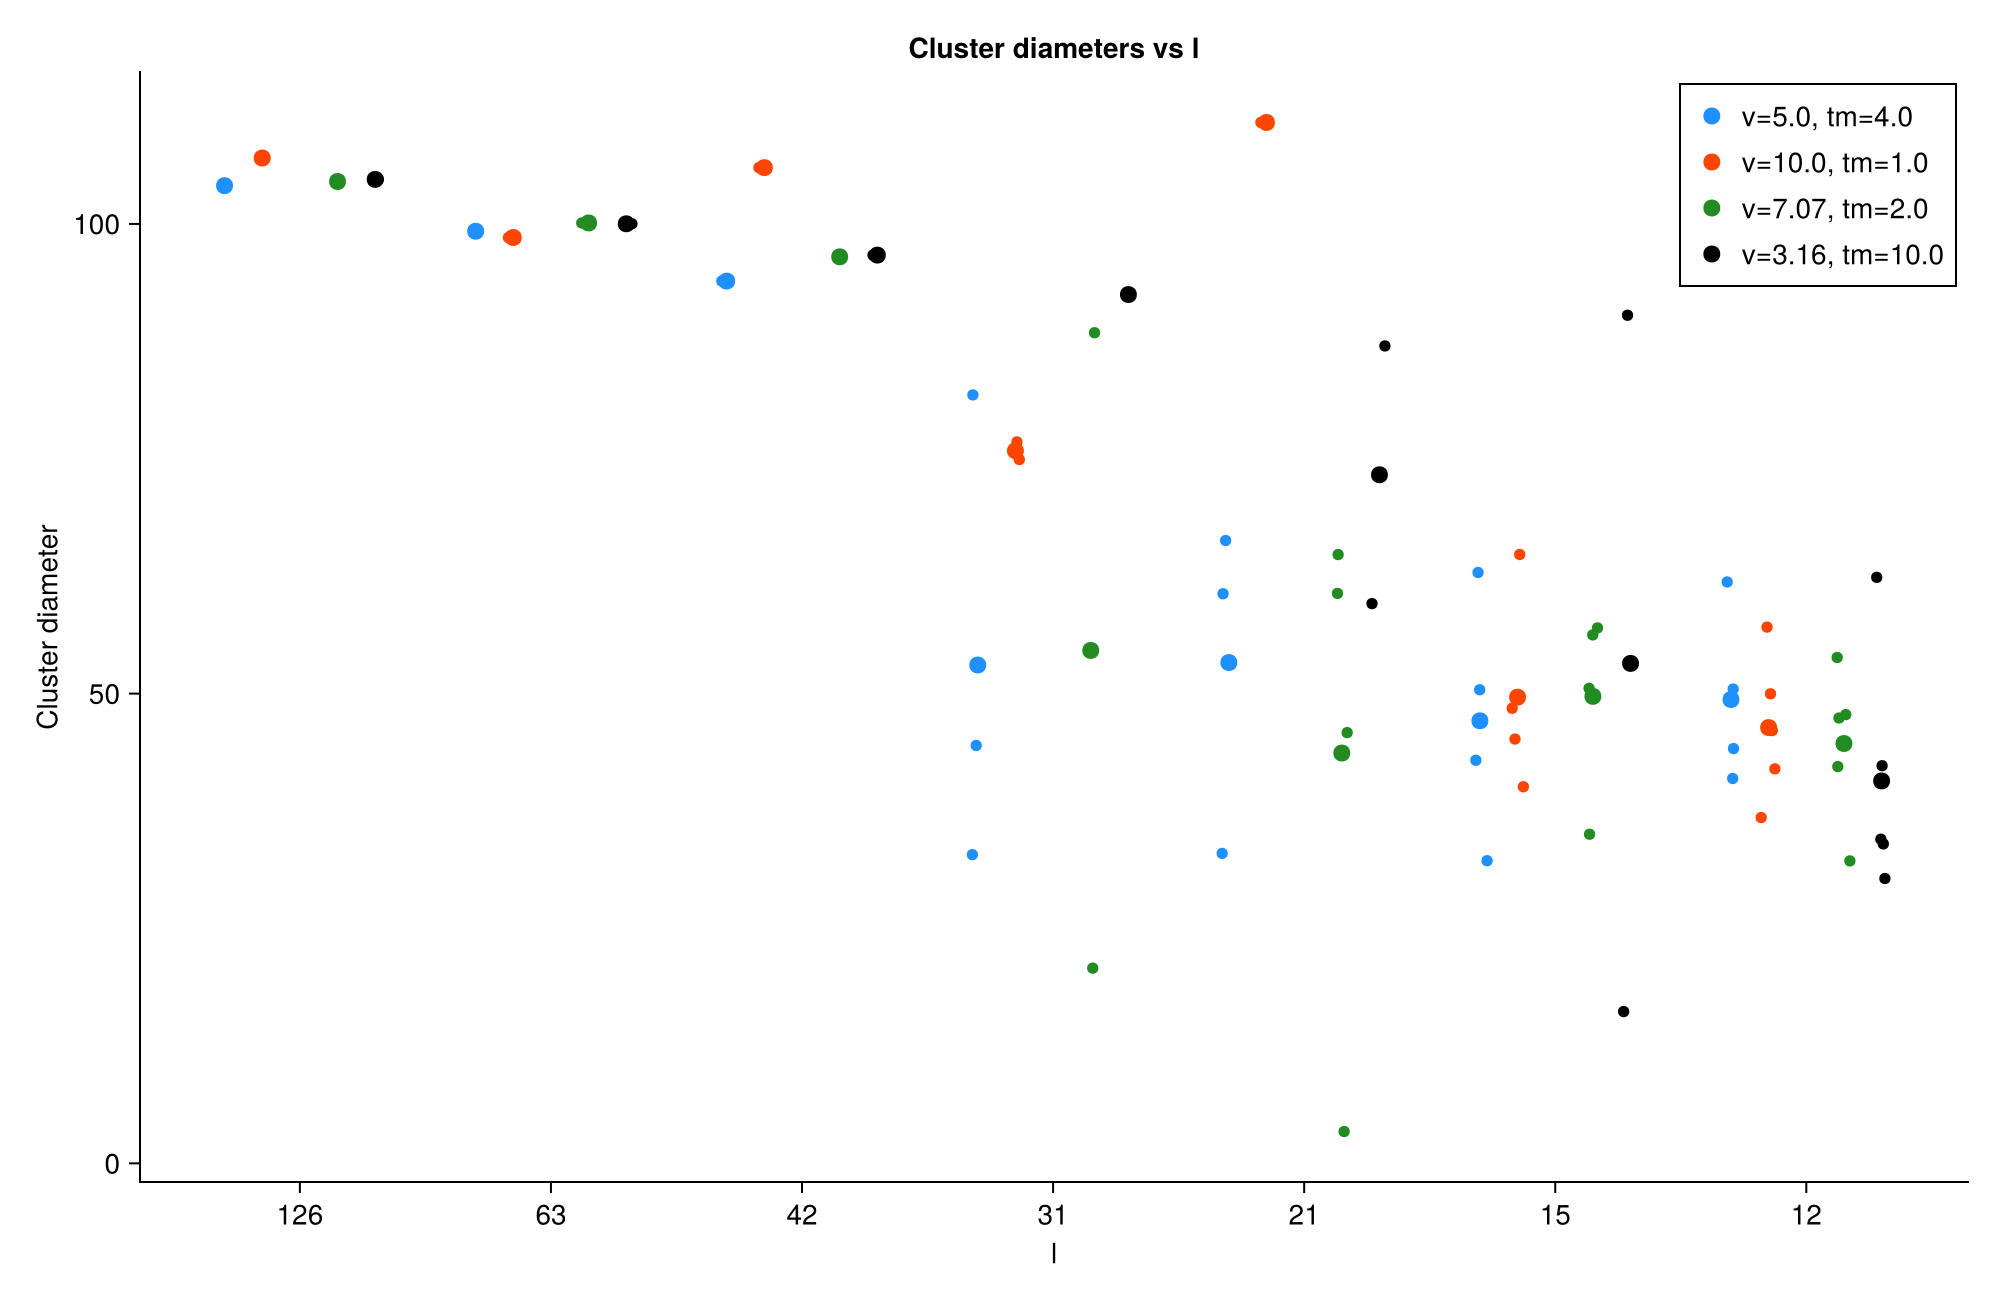

In [77]:
using CairoMakie
using Statistics

fig = Figure(size = (1000, 650))

ax = CairoMakie.Axis(
    fig[1,1],
    title = "Cluster diameters vs l",
    xlabel = "l",
    ylabel = "Cluster diameter"
)

# offsets = [-0.25, 0.0, 0.25]

# colors = [:dodgerblue, :orangered, :forestgreen]

# labels = [
#     "v=$(vs[1]), tm=$(tms[1])",
#     "v=$(vs[2]), tm=$(tms[2])",
#     "v=$(vs[3]), tm=$(tms[3])"
# ]

for j in eachindex(vs)

    mean_x = Float64[]
    mean_y = Float64[]

    for i in eachindex(ls)

        diams = all_diams[i,j]

        if isempty(diams)
            continue
        end

        x = i .+ offsets[j] .+ 0.06 .* (rand(length(diams)) .- 0.5)

        # individual cluster diameters
        scatter!(
            ax,
            x,
            diams,
            color = colors[j],
            markersize = 8,
            alpha = 1.0
        )

        # mean diameter
        push!(mean_x, i + offsets[j])
        push!(mean_y, mean(diams))
    end

    # lines!(
    #     ax,
    #     mean_x,
    #     mean_y,
    #     color = colors[j],
    #     linewidth = 3,
    #     label = labels[j]
    # )

    scatter!(
        ax,
        mean_x,
        mean_y,
        color = colors[j],
        markersize = 12,
        label = labels[j]
    )
end

ax.xticks = (1:length(ls), string.(ls))

ax.topspinevisible = false
ax.rightspinevisible = false
ax.xgridvisible = false
ax.ygridvisible = false

axislegend(ax, position = :rt)

fig